# Exploratory Data Analysis (EDA)


Perform EDA on US stocks and ETFs collected from Yahoo Finance.



## 1. Import Libraries

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

plt.style.use('default')

pd.set_option('display.max_columns', None)


# 2. Load Datasets

The datasets generated during Week 2 are loaded.

The datasets include:

- Adjusted close prices
- Daily returns
- Log returns
- Normalized prices
- Rolling volatility

In [2]:
adj_close = pd.read_csv(
    "../data/cleaned/adj_close_cleaned.csv",
    index_col=0,
    parse_dates=True
)

returns = pd.read_csv(
    "../data/processed/returns.csv",
    index_col=0,
    parse_dates=True
)

log_returns = pd.read_csv(
    "../data/processed/log_returns.csv",
    index_col=0,
    parse_dates=True
)

normalized_prices = pd.read_csv(
    "../data/processed/normalized_prices.csv",
    index_col=0,
    parse_dates=True
)

rolling_volatility = pd.read_csv(
    "../data/processed/rolling_volatility.csv",
    index_col=0,
    parse_dates=True
)

print("Datasets loaded successfully.")

Datasets loaded successfully.


# 3. Dataset Overview
To verify data is suitable for EDA we need to check these
- Number of assets
- Trading period
- Missing values
- Data types
- Summary statistics

In [3]:
print("Adjusted Close Shape:", adj_close.shape)
print("Returns Shape:", returns.shape)
print("Log Returns Shape:", log_returns.shape)
print("Rolling Volatility Shape:", rolling_volatility.shape)

Adjusted Close Shape: (2115, 108)
Returns Shape: (2114, 108)
Log Returns Shape: (2114, 108)
Rolling Volatility Shape: (2114, 108)


In [4]:
adj_close.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2115 entries, 2018-01-02 to 2026-06-02
Columns: 108 entries, AAPL to XOM
dtypes: float64(108)
memory usage: 1.8 MB


In [5]:
adj_close.describe()

,AAPL,ABBV,ABT,ADI,AMAT,AMD,AMGN,AMZN,ANET,APH,AVGO,AXP,BA,BAC,BKNG,BLK,BRK-B,BX,C,CAT,CB,CDNS,COP,COST,CRM,CSCO,CVX,DE,DELL,DHR,DIA,DIS,ETN,GE,GILD,GLD,GLW,GOOG,GOOGL,GS,HD,HON,IBKR,IBM,INTC,ISRG,IWM,JNJ,JPM,KLAC,KO,LIN,LLY,LMT,LOW,LRCX,MA,MCD,META,MO,MRK,MS,MSFT,MU,NEE,NEM,NFLX,NOW,NVDA,ORCL,PANW,PEP,PFE,PG,PLD,PM,QCOM,QQQ,RTX,SCHW,SPGI,SPY,STX,T,TJX,TLT,TMO,TMUS,TSLA,TXN,UNH,UNP,V,VNQ,VZ,WDC,WELL,WFC,WMT,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY,XOM
count,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000,2115.000000
mean,141.842500,119.875628,95.456026,157.999009,123.141025,98.820506,220.664585,144.942871,47.122172,47.005259,96.706977,170.861504,233.020599,32.741954,111.206833,663.912715,314.833168,83.514775,57.966146,244.163888,190.098431,173.789792,73.269782,511.336906,205.356254,47.351269,114.491763,310.097276,61.329540,188.665800,316.959575,116.527296,176.109792,103.148604,69.786606,196.695418,39.223226,125.674876,125.169209,354.471805,270.323023,165.327854,25.132892,140.936708,40.444944,302.758624,181.595828,141.807869,149.891735,445.168928,51.782936,299.199818,395.343044,375.058545,171.006880,61.668594,359.517320,222.511111,329.826607,37.557833,78.924885,78.152127,270.462105,93.931505,61.888994,47.997779,53.089154,104.512895,51.726103,95.316987,95.848242,131.786029,28.608576,123.124962,96.574237,88.124997,114.127883,337.153371,91.528422,60.925798,350.752399,407.839296,92.781952,17.239281,77.202447,101.373246,444.595046,132.590477,193.779305,143.764146,362.532959,187.245378,221.369979,75.845768,37.534855,59.894431,86.587732,47.447667,54.171176,31.542823,33.718772,97.493183,75.011835,62.720926,30.010593,114.047048,78.542554,76.717956
std,71.283198,51.463843,22.100803,66.167367,80.439730,69.184390,57.837379,50.474677,41.489719,33.408449,103.534150,80.655128,71.915825,9.230881,48.532571,229.630956,107.895018,44.562754,20.062040,158.689887,65.750313,99.206810,28.826185,275.423234,55.692667,13.235061,34.325776,133.455091,47.849825,58.699334,82.775525,26.243814,105.913932,83.121287,24.066925,81.195454,27.842480,71.511396,71.439177,204.487075,77.289708,32.242920,18.381377,61.210388,13.092205,129.386770,37.974289,29.280500,70.058891,378.743356,11.776307,116.322165,311.883481,91.772158,59.940737,52.601171,116.218480,55.649512,185.030473,11.118795,21.694642,40.569634,126.750558,103.544296,15.735029,20.494128,27.205631,49.723040,61.815546,57.050912,60.246076,26.152015,5.773694,29.636443,26.659508,36.210617,42.722255,142.591191,35.331167,19.107863,109.157003,137.808052,110.439901,4.250761,34.007986,17.828896,131.602041,55.252389,132.510293,41.460333,115.267591,40.785187,66.836406,11.424937,4.705529,69.103096,43.687596,16.909290,26.809694,11.263084,10.089335,30.883116,35.329921,12.548242,6.904557,25.146086,21.546295,31.440890
min,3

In [6]:
print("Missing Values:")
adj_close.isnull().sum().sort_values(ascending=False).head(10)

Missing Values:


AAPL    0
NVDA    0
SCHW    0
RTX     0
QQQ     0
QCOM    0
PM      0
PLD     0
PG      0
PFE     0
dtype: int64

In [7]:
print("Start Date:", adj_close.index.min())
print("End Date:", adj_close.index.max())

Start Date: 2018-01-02 00:00:00
End Date: 2026-06-02 00:00:00


# 4. Price Trend Analysis



In [8]:
# Asset Availability Check
print(adj_close.columns.tolist())

['AAPL', 'ABBV', 'ABT', 'ADI', 'AMAT', 'AMD', 'AMGN', 'AMZN', 'ANET', 'APH', 'AVGO', 'AXP', 'BA', 'BAC', 'BKNG', 'BLK', 'BRK-B', 'BX', 'C', 'CAT', 'CB', 'CDNS', 'COP', 'COST', 'CRM', 'CSCO', 'CVX', 'DE', 'DELL', 'DHR', 'DIA', 'DIS', 'ETN', 'GE', 'GILD', 'GLD', 'GLW', 'GOOG', 'GOOGL', 'GS', 'HD', 'HON', 'IBKR', 'IBM', 'INTC', 'ISRG', 'IWM', 'JNJ', 'JPM', 'KLAC', 'KO', 'LIN', 'LLY', 'LMT', 'LOW', 'LRCX', 'MA', 'MCD', 'META', 'MO', 'MRK', 'MS', 'MSFT', 'MU', 'NEE', 'NEM', 'NFLX', 'NOW', 'NVDA', 'ORCL', 'PANW', 'PEP', 'PFE', 'PG', 'PLD', 'PM', 'QCOM', 'QQQ', 'RTX', 'SCHW', 'SPGI', 'SPY', 'STX', 'T', 'TJX', 'TLT', 'TMO', 'TMUS', 'TSLA', 'TXN', 'UNH', 'UNP', 'V', 'VNQ', 'VZ', 'WDC', 'WELL', 'WFC', 'WMT', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY', 'XOM']


In [9]:
for ticker in ['AAPL', 'MSFT', 'NVDA', 'SPY']:
    print(ticker, ticker in adj_close.columns)

AAPL True
MSFT True
NVDA True
SPY True


In [10]:
adj_close.columns[:20]

Index(['AAPL', 'ABBV', 'ABT', 'ADI', 'AMAT', 'AMD', 'AMGN', 'AMZN', 'ANET',
       'APH', 'AVGO', 'AXP', 'BA', 'BAC', 'BKNG', 'BLK', 'BRK-B', 'BX', 'C',
       'CAT'],
      dtype='str')

In [11]:
major_assets = [
    'AAPL',
    'MSFT',
    'NVDA',
    'SPY'
]


The price trends of selected technology stocks and a broad market benchmark are analyzed to compare their performance and identify major market movements during the sample period.

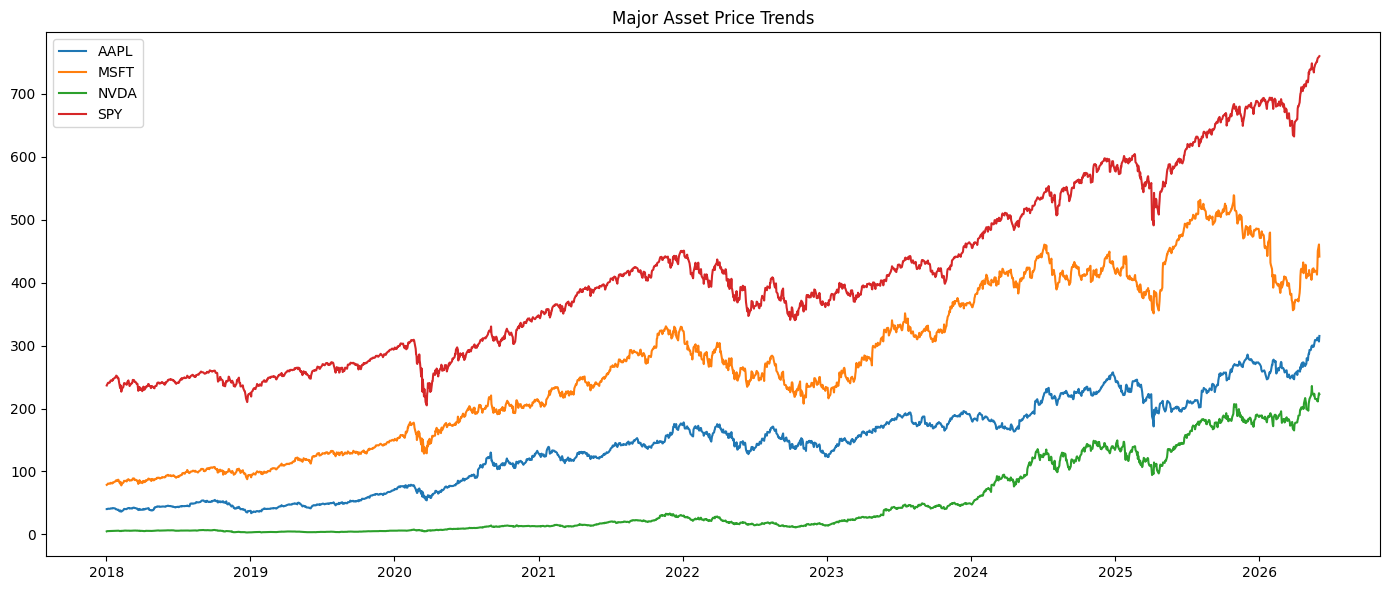

In [12]:
plt.figure(figsize=(14,6))

for asset in major_assets:
    plt.plot(
        adj_close.index,
        adj_close[asset],
        label=asset
    )

plt.title("Major Asset Price Trends")
plt.legend()
plt.tight_layout()
plt.show()

### Normalized Price Comparison

Since assets begin the sample period at different price levels, direct comparison of raw prices can be misleading. By normalizing the price level for all of them, we can make an objective judgment regarding their performance.


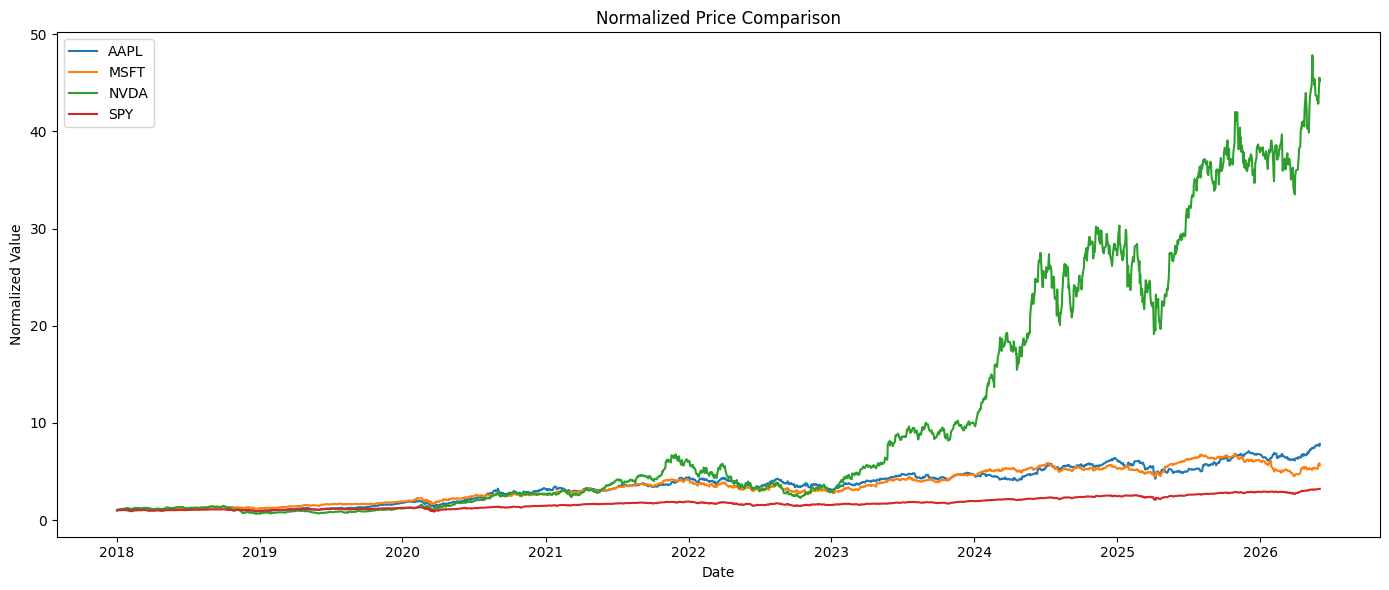

In [13]:

plt.figure(figsize=(14,6))

for asset in major_assets:
    plt.plot(
        normalized_prices.index,
        normalized_prices[asset],
        label=asset
    )

plt.title("Normalized Price Comparison")
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Top Performing Assets

Using normalized prices, the final value of each asset represents its cumulative growth relative to the start of the sample period.


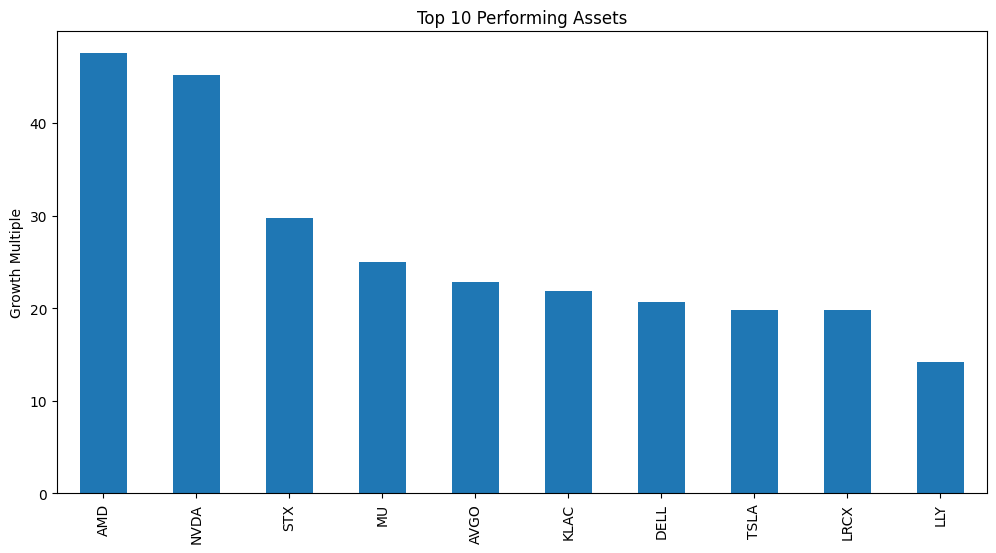

AMD     47.499089
NVDA    45.212658
STX     29.703806
MU      24.984274
AVGO    22.837663
KLAC    21.852634
DELL    20.680380
TSLA    19.829968
LRCX    19.821289
LLY     14.208033
Name: 2026-06-02 00:00:00, dtype: float64


<Figure size 640x480 with 0 Axes>

In [14]:
performance = (
    normalized_prices.iloc[-1]
    .sort_values(ascending=False)
)

top10 = performance.head(10)

plt.figure(figsize=(12,6))

top10.plot(kind='bar')

plt.title("Top 10 Performing Assets")
plt.ylabel("Growth Multiple")

plt.show()
plt.tight_layout()
print(top10)

Bottom Performing Assets

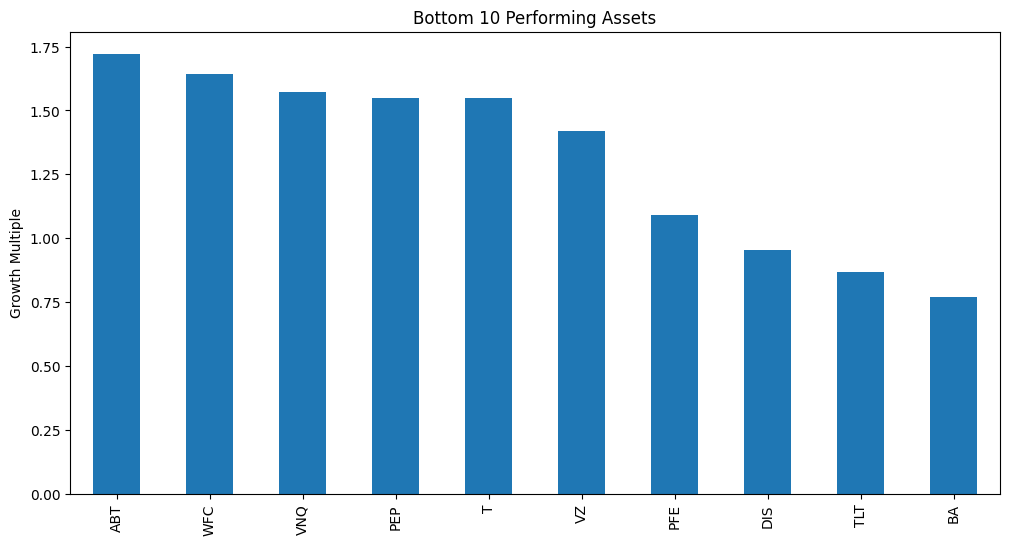

ABT    1.721971
WFC    1.642112
VNQ    1.570857
PEP    1.550171
T      1.547632
VZ     1.419929
PFE    1.089857
DIS    0.954676
TLT    0.867731
BA     0.769567
Name: 2026-06-02 00:00:00, dtype: float64


<Figure size 640x480 with 0 Axes>

In [15]:
bottom10 = performance.tail(10)

plt.figure(figsize=(12,6))

bottom10.plot(kind='bar')

plt.title("Bottom 10 Performing Assets")
plt.ylabel("Growth Multiple")

plt.show()
plt.tight_layout()
print(bottom10)

# 6. Return Analysis

Daily returns are analyzed to understand the performance and risk characteristics of the assets. Unlike raw prices, returns allow meaningful comparison across securities with different price levels.

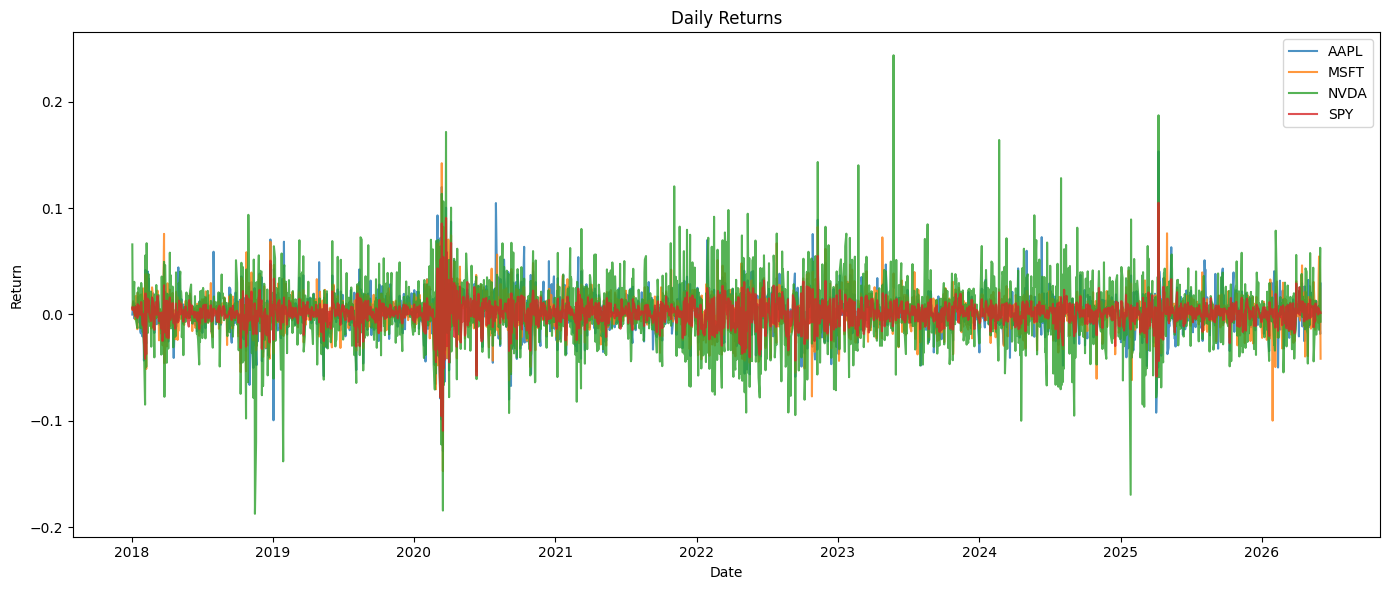

In [16]:
assets = [
    'AAPL',
    'MSFT',
    'NVDA',
    'SPY'
]

plt.figure(figsize=(14,6))

for asset in assets:
    plt.plot(
        returns.index,
        returns[asset],
        label=asset,
        alpha=0.8
    )

plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Return Summary Statistics

In [17]:
return_stats = pd.DataFrame({
    'Mean Return': returns.mean(),
    'Volatility': returns.std(),
    'Min Return': returns.min(),
    'Max Return': returns.max()
})

return_stats.head()

,Mean Return,Volatility,Min Return,Max Return
AAPL,0.001158,0.019208,-0.128647,0.153289
ABBV,0.000683,0.016813,-0.162524,0.137673
ABT,0.000378,0.015552,-0.100389,0.109360
ADI,0.001038,0.021651,-0.166149,0.183876
AMAT,0.001500,0.028359,-0.203576,0.161057


In [18]:
log_return_stats = pd.DataFrame({
    'Mean': log_returns.mean(),
    'Volatility': log_returns.std(),
    'Skewness': log_returns.skew(),
    'Kurtosis': log_returns.kurtosis()
})

log_return_stats.head()

,Mean,Volatility,Skewness,Kurtosis
AAPL,0.000973,0.019188,-0.089207,6.189352
ABBV,0.000540,0.016965,-1.278722,14.922425
ABT,0.000257,0.015580,-0.350279,6.820041
ADI,0.000804,0.021623,-0.084459,7.646644
AMAT,0.001096,0.028467,-0.448760,4.125764


## 8. Outlier Detection
To show extreme market moves

In [19]:
z_scores = (
    returns - returns.mean()
) / returns.std()

outliers = (
    z_scores.abs() > 3
)

outliers.sum().sort_values(
    ascending=False
).head(10)

GLW     42
QCOM    41
AMGN    39
ISRG    39
MRK     39
TMUS    38
IBM     38
JNJ     38
KO      38
UNH     37
dtype: int64

## 9. Most Volatile Assets

The following assets exhibited the highest return volatility during the sample period, indicating greater price fluctuations and risk.

In [20]:
top_volatility = (
    returns.std()
    .sort_values(ascending=False)
    .head(10)
)

top_volatility

TSLA    0.039487
AMD     0.035339
MU      0.032353
NVDA    0.031928
WDC     0.031726
LRCX    0.029750
INTC    0.029632
DELL    0.029339
ANET    0.029107
AMAT    0.028359
dtype: float64

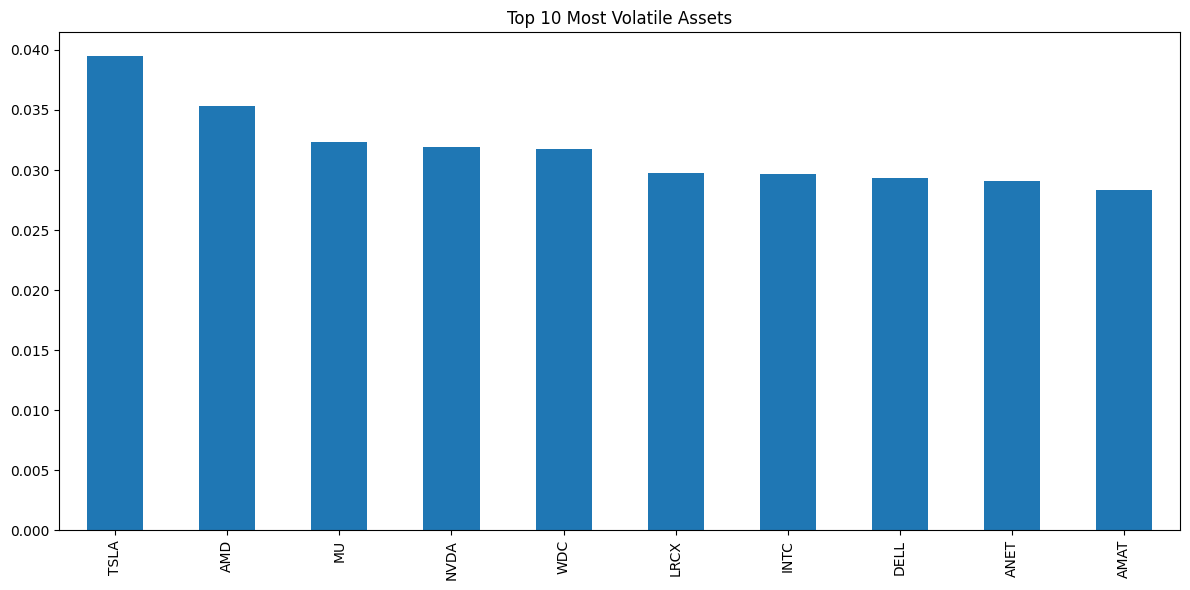

In [21]:
plt.figure(figsize=(12,6))

top_volatility.plot(kind='bar')

plt.title("Top 10 Most Volatile Assets")
plt.tight_layout()
plt.show()

### Least Volatile Assets

The assets below exhibited the lowest return volatility during the sample period, indicating more stable price movements and lower levels of market risk.

In [22]:
low_volatility = (
    returns.std()
    .sort_values()
    .head(10)
)

low_volatility

TLT    0.009767
XLP    0.009809
GLD    0.010467
XLV    0.010974
DIA    0.011833
SPY    0.012095
KO     0.012105
JNJ    0.012257
PG     0.012628
XLU    0.012765
dtype: float64

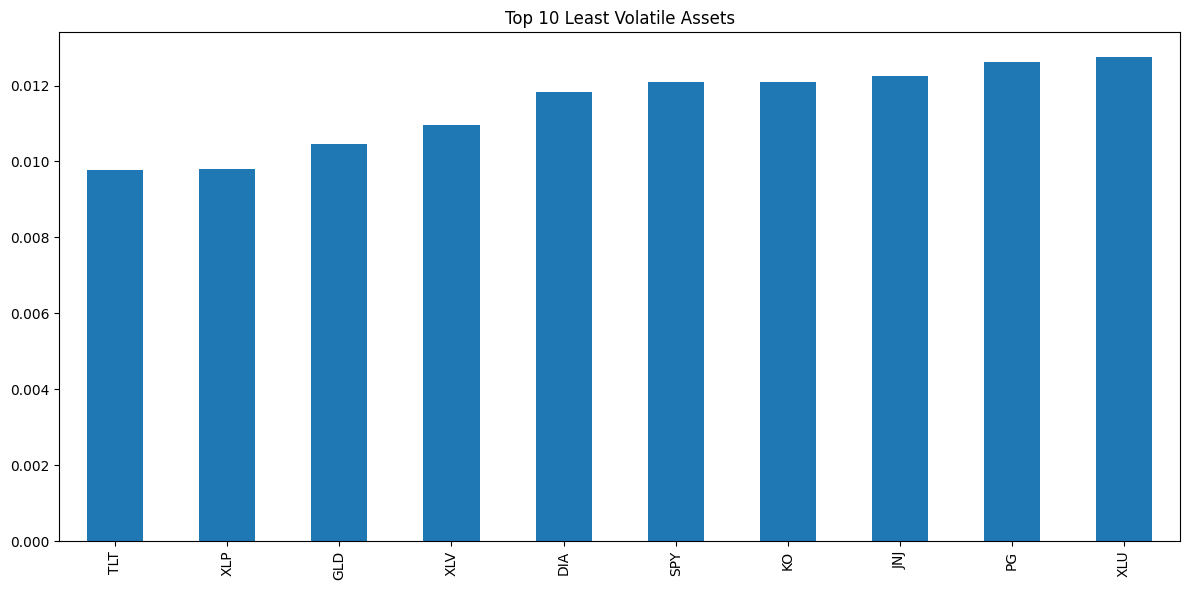

In [23]:
plt.figure(figsize=(12,6))

low_volatility.plot(kind='bar')

plt.title("Top 10 Least Volatile Assets")
plt.tight_layout()
plt.show()

## 10. Rolling Volatility Analysis
It shows 
- Covid crash
- Bear market
- Market Stress periods

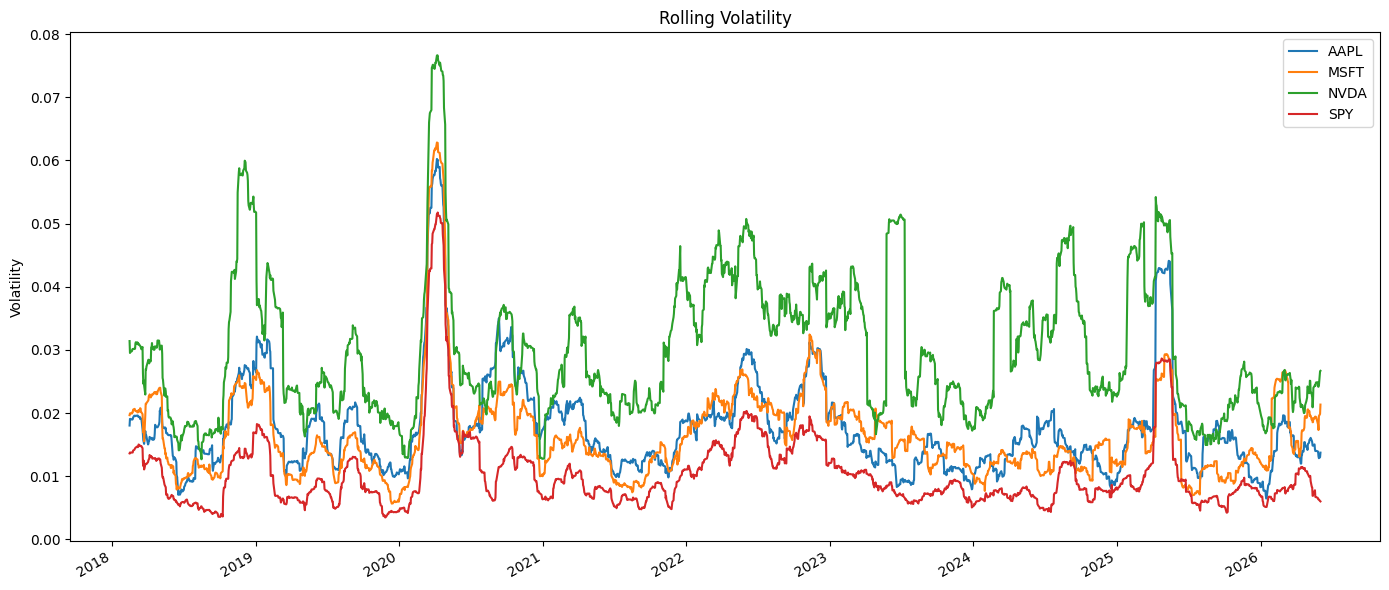

In [24]:
rolling_volatility[
    ['AAPL','MSFT','NVDA','SPY']
].plot(
    figsize=(14,6)
)

plt.title("Rolling Volatility")
plt.ylabel("Volatility")
plt.tight_layout()
plt.show()

## 11. Return Distribution Analysis

The distribution of returns is examined to understand the frequency of different return outcomes and assess the presence of skewness and extreme market movements.

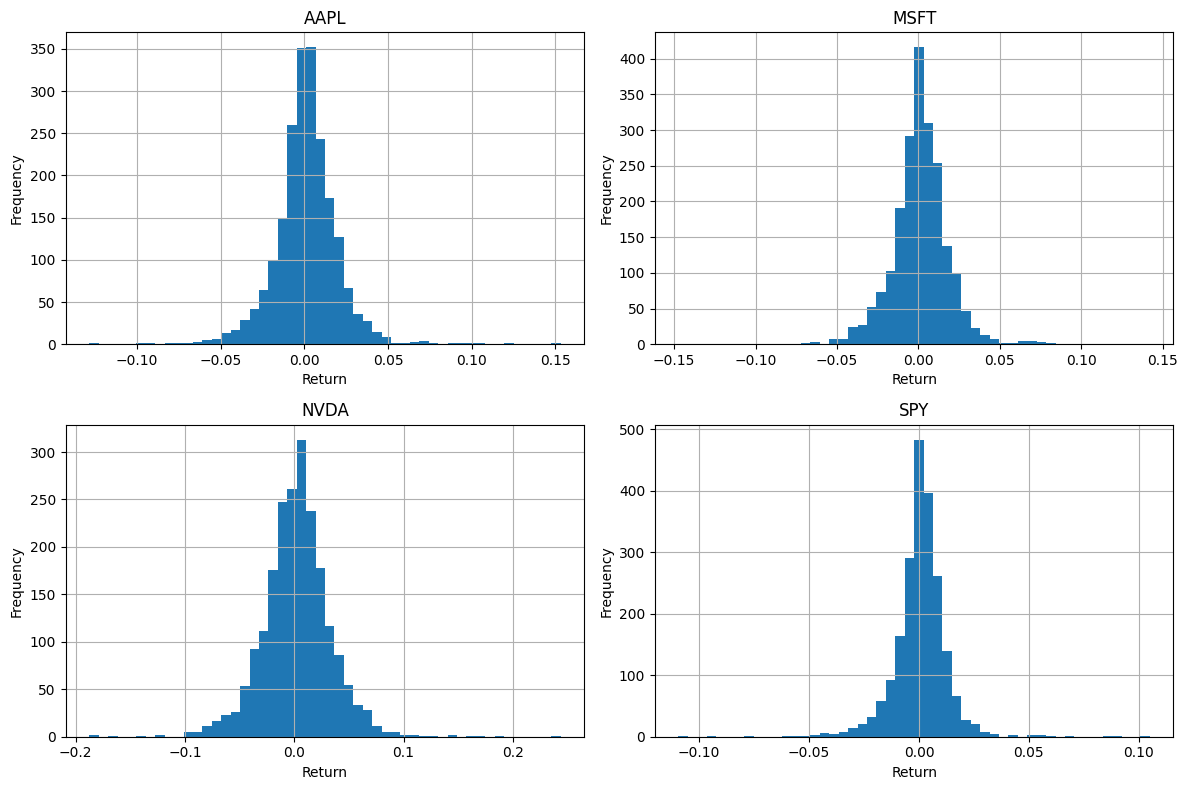

In [25]:
assets = ['AAPL','MSFT','NVDA','SPY']

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

for ax, asset in zip(
    axes.flatten(),
    assets
):

    returns[asset].hist(
        bins=50,
        ax=ax
    )

    ax.set_title(asset)
    ax.set_xlabel("Return")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 12. Skewness and Kurtosis

In [26]:
distribution_stats = pd.DataFrame({
    'Skewness': returns.skew(),
    'Kurtosis': returns.kurtosis()
})

distribution_stats.head()

,Skewness,Kurtosis
AAPL,0.147768,6.414068
ABBV,-0.905763,12.797567
ABT,-0.148661,6.617357
ADI,0.225820,7.670579
AMAT,-0.207340,3.414640


### Assets with Highest Kurtosis

Ranking assets by kurtosis helps identify securities whose return distributions exhibit the strongest tail behavior and the greatest tendency toward extreme return events.

In [27]:
distribution_stats.sort_values(
    'Kurtosis',
    ascending=False
).head(10)

,Skewness,Kurtosis
ORCL,2.217203,34.272521
MCD,0.353737,29.836753
WELL,0.094081,27.927466
CVX,-0.321470,22.968726
DELL,1.312437,20.883697
UNH,-1.363840,20.777127
VNQ,-1.092201,19.706740
DIA,-0.475080,19.002511
LOW,-0.951482,18.777288
NFLX,-0.875824,18.675214


## 13. Correlation Matrix

The correlation matrix summarizes pairwise relationships between asset returns, where values close to 1 indicate strong positive co-movement and values close to -1 indicate strong inverse relationships.

In [28]:
corr_matrix = returns.corr()

corr_matrix.head()

,AAPL,ABBV,ABT,ADI,AMAT,AMD,AMGN,AMZN,ANET,APH,AVGO,AXP,BA,BAC,BKNG,BLK,BRK-B,BX,C,CAT,CB,CDNS,COP,COST,CRM,CSCO,CVX,DE,DELL,DHR,DIA,DIS,ETN,GE,GILD,GLD,GLW,GOOG,GOOGL,GS,HD,HON,IBKR,IBM,INTC,ISRG,IWM,JNJ,JPM,KLAC,KO,LIN,LLY,LMT,LOW,LRCX,MA,MCD,META,MO,MRK,MS,MSFT,MU,NEE,NEM,NFLX,NOW,NVDA,ORCL,PANW,PEP,PFE,PG,PLD,PM,QCOM,QQQ,RTX,SCHW,SPGI,SPY,STX,T,TJX,TLT,TMO,TMUS,TSLA,TXN,UNH,UNP,V,VNQ,VZ,WDC,WELL,WFC,WMT,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY,XOM
AAPL,1.000000,0.280315,0.426957,0.579981,0.546367,0.489075,0.368808,0.583109,0.410857,0.518023,0.513459,0.461243,0.403958,0.435640,0.424044,0.562986,0.516895,0.513900,0.442797,0.394927,0.326371,0.549512,0.303597,0.490520,0.497930,0.532037,0.332250,0.388208,0.368282,0.467179,0.688054,0.430253,0.457718,0.347254,0.276531,0.057356,0.465698,0.608891,0.607272,0.486935,0.513682,0.471098,0.393058,0.372673,0.420333,0.544648,0.594772,0.312404,0.427418,0.558973,0.348084,0.488163,0.279398,0.259830,0.473213,0.546160,0.576465,0.392256,0.522349,0.239297,0.284364,0.501373,0.669091,0.446273,0.321431,0.129729,0.429556,0.493069,0.561453,0.357709,0.415706,0.398692,0.294584,0.354105,0.489041,0.281606,0.551907,0.806870,0.345495,0.353043,0.519545,0.767805,0.397982,0.263092,0.409410,-0.085613,0.464023,0.362517,0.454572,0.567407,0.297795,0.451320,0.568397,0.498332,0.211163,0.398666,0.272968,0.374565,0.332276,0.347322,0.539858,0.582157,0.810314,0.491323,0.354307,0.553360,0.693260,0.290283
ABBV,0.280315,1.000000,0.406557,0.275108,0.253938,0.165665,0.477378,0.172483,0.182386,0.282866,0.198493,0.298102,0.224529,0.313915,0.219446,0.337618,0.403489,0.269052,0.310566,0.286090,0.345150,0.223963,0.286002,0.264530,0.209328,0.352831,0.317678,0.285747,0.156481,0.377070,0.463480,0.233679,0.280188,0.228161,0.383905,0.011915,0.299513,0.263288,0.265382,0.292628,0.341376,0.341698,0.221266,0.295719,0.247854,0.301970,0.340748,0.446640,0.324937,0.226722,0.373574,0.356058,0.374500,0.277283,0.316346,0.237090,0.358640,0.322072,0.174769,0.282417,0.445849,0.302540,0.293224,0.202811,0.267161,0.084688,0.148762,0.212495,0.188956,0.188969,0.163292,0.380311,0.447737,0.348741,0.320114,0.316860,0.208806,0.331987,0.323841,0.240925,0.316133,0.426740,0.199159,0.303700,0.301685,-0.078184,0.362961,0.284060,0.117229,0.296382,0.329486,0.321411,0.380905,0.369141,0.293083,0.199886,0.263194,0.284122,0.250676,0.319024,0.395174,0.393892,0.324068,0.437559,0.323671,0.628691,0.301656,0.278177
ABT,0.426957,0.406557,1.000000,0.393796,0.319572,0.265472,0.437080,0.317137,0.260459,0.360762,0.267874,0.361015,0.280144,0.377287,0.301563,0.486857,0.492298,0.399365,0.337412,0.304579,0.377101,0.392282,0.210128,0.419244,0.367830,0.432885,0.286889,0.341836,0.186893,0.552866,0.573953,0.322435,0.350679,0.283947,0.370510,0.069560,0.352325,0.370114,0.372316,0.364113,0.454208,0.448717,0.296486,0.356974,0.273788,0.533120,0.439259,0.530861,0.375293,0.335910,0.445035,0.476895,0.334309,0.334367,0.418541,0.316833,0.492695,0.416569,0.282021,0.311481,0.415909,0.398984,0.461117,0.250519,0.393189,0.157758,0.250239,0.366428,0.322574,0.239898,0.259568,0.454206,0.399556,0.464806,0.505067,0.334707,0.299070,0.499097,0.327991,0.329004,0.485008,0.567756,0.236371,0.353240,0.366805,-0.091411,0.566389,0.366611,0.189255,0.383502,0.366687,0.403101,0.497022,0.493949,0.345402,0.234594,0.230618,0.314001,0.321683,0.256616,0.484920,0.499265,0.480840,0.562202,0.468999,0.721494,0.443247,0.228753
ADI,0.579981,0.275108,0.393796,1.000000,0.735784,0.549317,0.348785,0.484971,0.437983,0.603665,0.620095,0.534897,0.430442,0.510991,0.483139,0.602275,0.513246,0.531894,0.520484,0.520625,0.337768,0.586545,0.365655,0.412829,0.445673,0.506120,0.401109,0.477854,0.426403,0.464053,0.677706,0.464814,0.567638,0.416922,0.267815,0.088077,0.554588,0.528687,0.531262,0.553957,0.511980,0.519729,0.437202,0.372640,0.533564,0.537336,0.688495,0.257266,0.507923,0.736454,0.288701,0.505364,0.234507,0.213973,0.481269,0.726352,0.534878,0.361541,0.457093,0.188068,0.250254,0.566122,0.548226,0.621008,0.285118,0.202482,0.343878,0.425188,0.59

### Correlation Heatmap

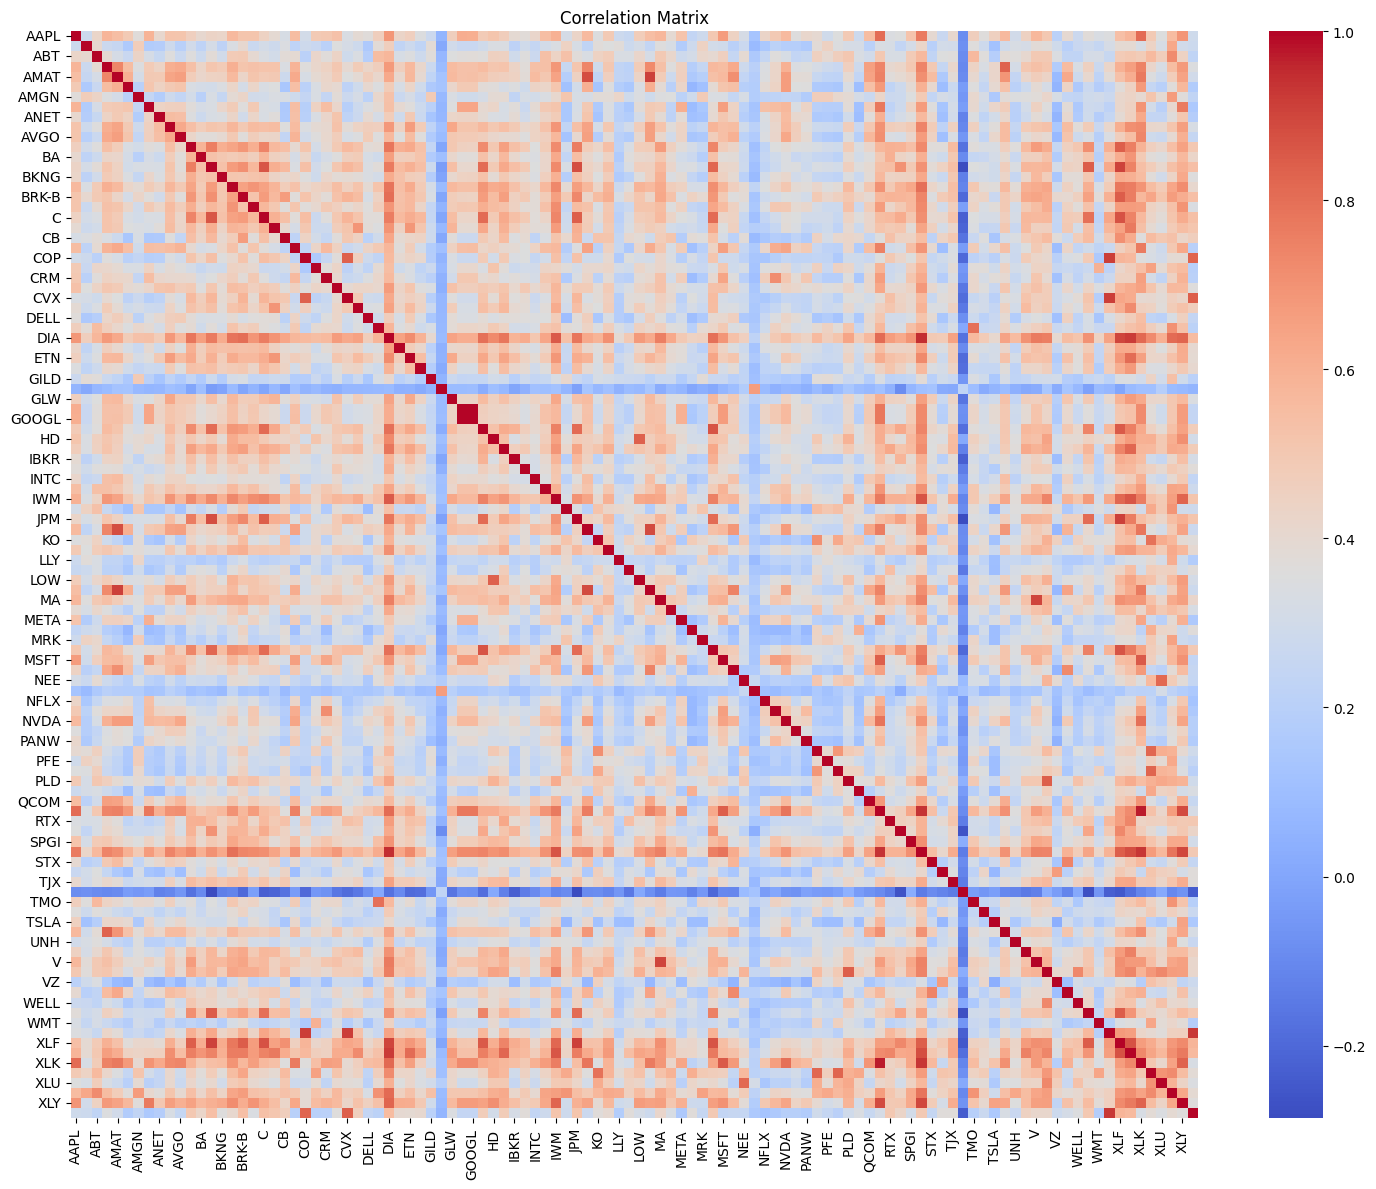

In [29]:
plt.figure(figsize=(15,12))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [30]:

# Upper triangle only to avoid duplicates
upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

corr_pairs = (
    upper
    .unstack()
    .dropna()
    .sort_values(ascending=False)
)

corr_pairs.head(20)

GOOGL  GOOG    0.995733
XLK    QQQ     0.973835
SPY    DIA     0.945355
       QQQ     0.937773
XLK    SPY     0.930450
XOM    XLE     0.926456
XLI    DIA     0.923974
XLE    CVX     0.918032
       COP     0.917622
XLF    JPM     0.911577
LRCX   AMAT    0.910904
XLF    BAC     0.905972
V      MA      0.902686
XLF    DIA     0.900219
XLY    SPY     0.897571
LRCX   KLAC    0.886498
XLY    QQQ     0.886041
KLAC   AMAT    0.883814
XLI    SPY     0.881887
JPM    BAC     0.881546
dtype: float64

## 14. Annual Return

In [31]:
annual_return = returns.mean() * 252

annual_return.sort_values(
    ascending=False
).head(10)

AMD     0.616168
NVDA    0.582926
TSLA    0.551695
MU      0.515431
STX     0.492784
DELL    0.467750
LRCX    0.467554
KLAC    0.464046
AVGO    0.458460
ANET    0.405532
dtype: float64

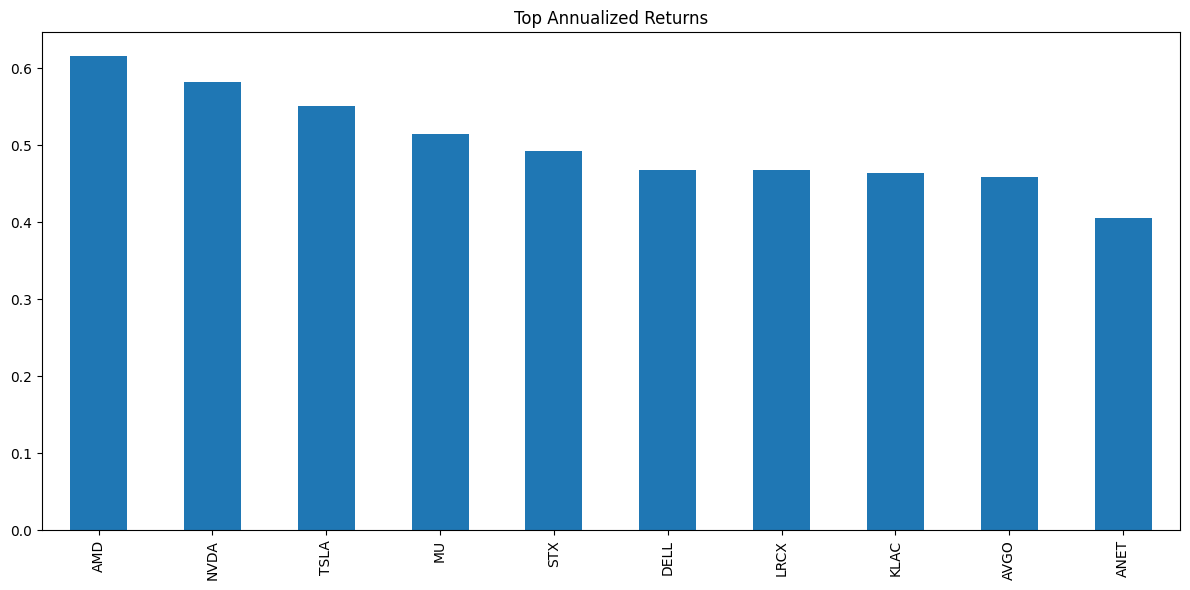

In [32]:
annual_return.sort_values(
    ascending=False
).head(10).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    "Top Annualized Returns"
)
plt.tight_layout()
plt.show()

## 15. Final Summary

In [33]:
corr_unstacked = corr_matrix.where(
    ~np.eye(corr_matrix.shape[0], dtype=bool)
).stack()

top_pair = corr_unstacked.idxmax()
top_corr = corr_unstacked.max()
annual_volatility = returns.std() * np.sqrt(252)

best_asset = annual_return.idxmax()
worst_asset = annual_return.idxmin()

most_volatile_asset = annual_volatility.idxmax()
least_volatile_asset = annual_volatility.idxmin()

final_summary = pd.DataFrame({
    "Metric": [
        "Number of Assets",
        "Analysis Period (Days)",
        "Average Daily Return",
        "Average Annualized Return",
        "Average Annualized Volatility",
        "Highest Correlation Pair",
        "Highest Correlation Value",
        "Best Performing Asset",
        "Worst Performing Asset",
        "Most Volatile Asset",
        "Least Volatile Asset"
    ],
    "Value": [
        returns.shape[1],
        len(returns),
        round(returns.mean().mean(), 6),
        round(annual_return.mean(), 4),
        round(annual_volatility.mean(), 4),
        f"{top_pair[0]} - {top_pair[1]}",
        round(top_corr, 4),
        best_asset,
        worst_asset,
        most_volatile_asset,
        least_volatile_asset
    ]
})

final_summary

,Metric,Value
0,Number of Assets,108
1,Analysis Period (Days),2114
2,Average Daily Return,0.000836
3,Average Annualized Return,0.2108
4,Average Annualized Volatility,0.3109
5,Highest Correlation Pair,GOOG - GOOGL
6,Highest Correlation Value,0.9957
7,Best Performing Asset,AMD
8,Worst Performing Asset,TLT
9,Most Volatile Asset,TSLA


In [34]:
# ============================================================
# Separate Stocks and ETFs
# ============================================================

etf_tickers = [
    'SPY',
    'QQQ',
    'IWM',
    'DIA',
    'XLK',
    'XLF',
    'XLV',
    'XLE',
    'XLY',
    'XLP',
    'XLI',
    'XLU',
    'VNQ',
    'GLD',
    'SLV',
    'TLT'
]

available_etfs = [
    ticker for ticker in etf_tickers
    if ticker in returns.columns
]

stock_columns = [
    col for col in returns.columns
    if col not in available_etfs
]

stock_returns = returns[stock_columns]
etf_returns = returns[available_etfs]

print("Number of Stocks:", len(stock_columns))
print("Number of ETFs:", len(available_etfs))

Number of Stocks: 93
Number of ETFs: 15


# 15. Top Correlated Stock Pairs

In [35]:
# ============================================================
# Stock Correlation Matrix
# ============================================================

stock_corr = stock_returns.corr()

upper = stock_corr.where(
    np.triu(
        np.ones(stock_corr.shape),
        k=1
    ).astype(bool)
)

top_stock_pairs = (
    upper
    .stack()
    .reset_index()
)

top_stock_pairs.columns = [
    "Stock_1",
    "Stock_2",
    "Correlation"
]

top_stock_pairs = (
    top_stock_pairs
    .sort_values(
        "Correlation",
        ascending=False
    )
    .head(20)
)

top_stock_pairs

,Stock_1,Stock_2,Correlation
3291,GOOG,GOOGL,0.995733
424,AMAT,LRCX,0.910904
5015,MA,V,0.902686
4330,KLAC,LRCX,0.886498
418,AMAT,KLAC,0.883814
1254,BAC,JPM,0.881546
3499,GS,MS,0.867667
1227,BAC,C,0.862913
1299,BAC,WFC,0.845897
2510,CVX,XOM,0.843423


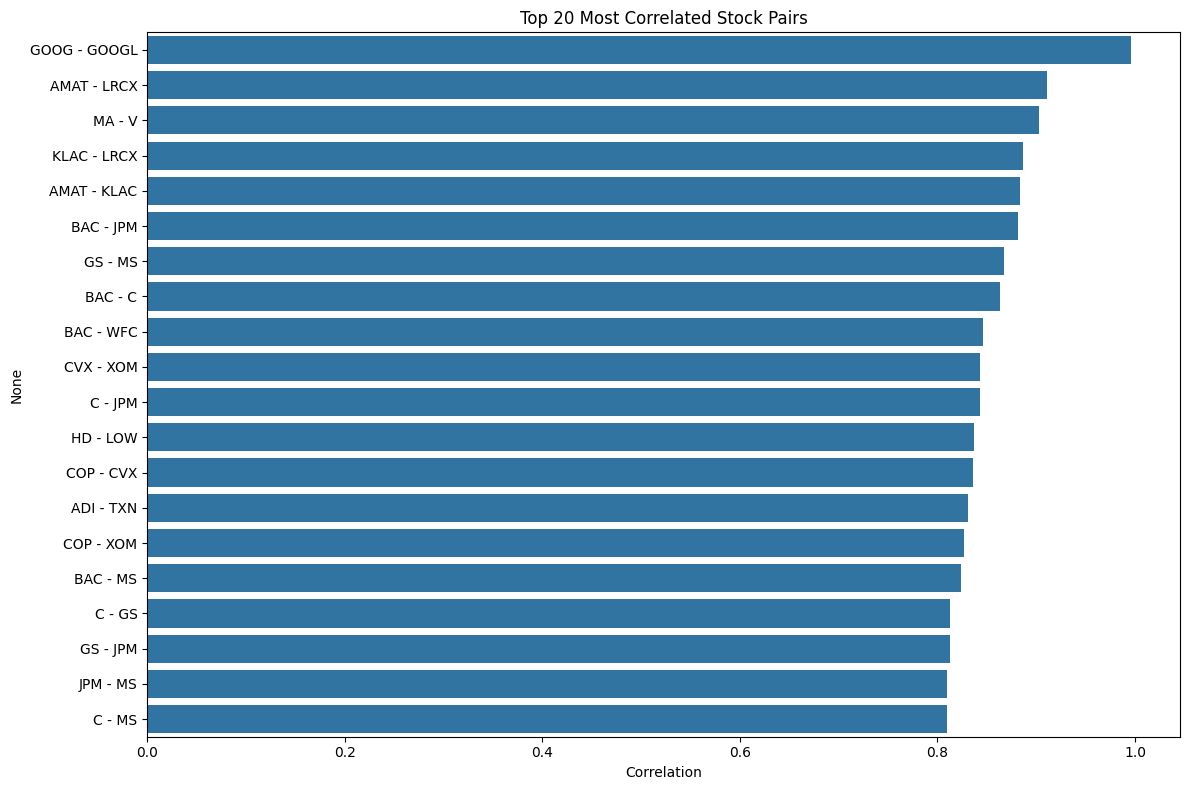

In [36]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=top_stock_pairs,
    x="Correlation",
    y=top_stock_pairs["Stock_1"]
      + " - "
      + top_stock_pairs["Stock_2"]
)

plt.title(
    "Top 20 Most Correlated Stock Pairs"
)

plt.tight_layout()
plt.show()

In [54]:
import time

sector_info = {}

for ticker in stock_columns:

    try:

        sector_info[ticker] = (
            yf.Ticker(ticker)
            .info
            .get("sector")
        )

        time.sleep(0.5)

    except Exception:

        sector_info[ticker] = "Unknown"

In [56]:
top_tickers = set(
    top_stock_pairs["Stock_1"]
).union(
    set(top_stock_pairs["Stock_2"])
)

sector_info = {}

for ticker in top_tickers:

    try:

        sector_info[ticker] = (
            yf.Ticker(ticker)
            .info
            .get("sector")
        )

    except:

        sector_info[ticker] = "Unknown"

In [57]:
top_stock_pairs["Sector_1"] = (
    top_stock_pairs["Stock_1"]
    .map(sector_info)
)

top_stock_pairs["Sector_2"] = (
    top_stock_pairs["Stock_2"]
    .map(sector_info)
)

top_stock_pairs.head()

,Stock_1,Stock_2,Correlation,Sector_1,Sector_2
3291,GOOG,GOOGL,0.995733,Communication Services,Communication Services
424,AMAT,LRCX,0.910904,Technology,Technology
5015,MA,V,0.902686,Financial Services,Financial Services
4330,KLAC,LRCX,0.886498,Technology,Technology
418,AMAT,KLAC,0.883814,Technology,Technology


# 16. Top Correlated ETF Pairs

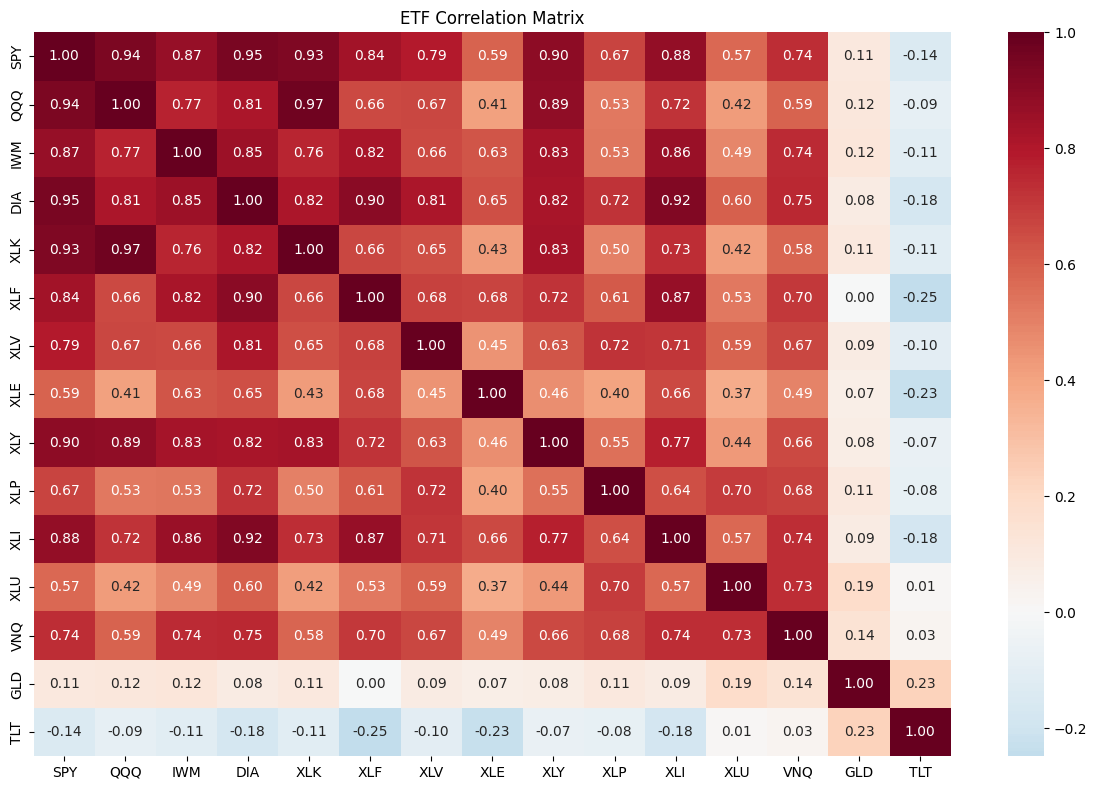

In [58]:
# ============================================================
# ETF Correlation Matrix
# ============================================================

etf_corr = etf_returns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    etf_corr,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("ETF Correlation Matrix")

plt.tight_layout()
plt.show()

In [59]:
upper_etf = etf_corr.where(
    np.triu(
        np.ones(etf_corr.shape),
        k=1
    ).astype(bool)
)

top_etf_pairs = (
    upper_etf
    .stack()
    .reset_index()
)

top_etf_pairs.columns = [
    "ETF_1",
    "ETF_2",
    "Correlation"
]

top_etf_pairs = (
    top_etf_pairs
    .sort_values(
        "Correlation",
        ascending=False
    )
    .head(15)
)

top_etf_pairs

,ETF_1,ETF_2,Correlation
19,QQQ,XLK,0.973835
3,SPY,DIA,0.945355
1,SPY,QQQ,0.937773
4,SPY,XLK,0.930450
55,DIA,XLI,0.923974
50,DIA,XLF,0.900219
8,SPY,XLY,0.897571
23,QQQ,XLY,0.886041
10,SPY,XLI,0.881887
85,XLF,XLI,0.870597


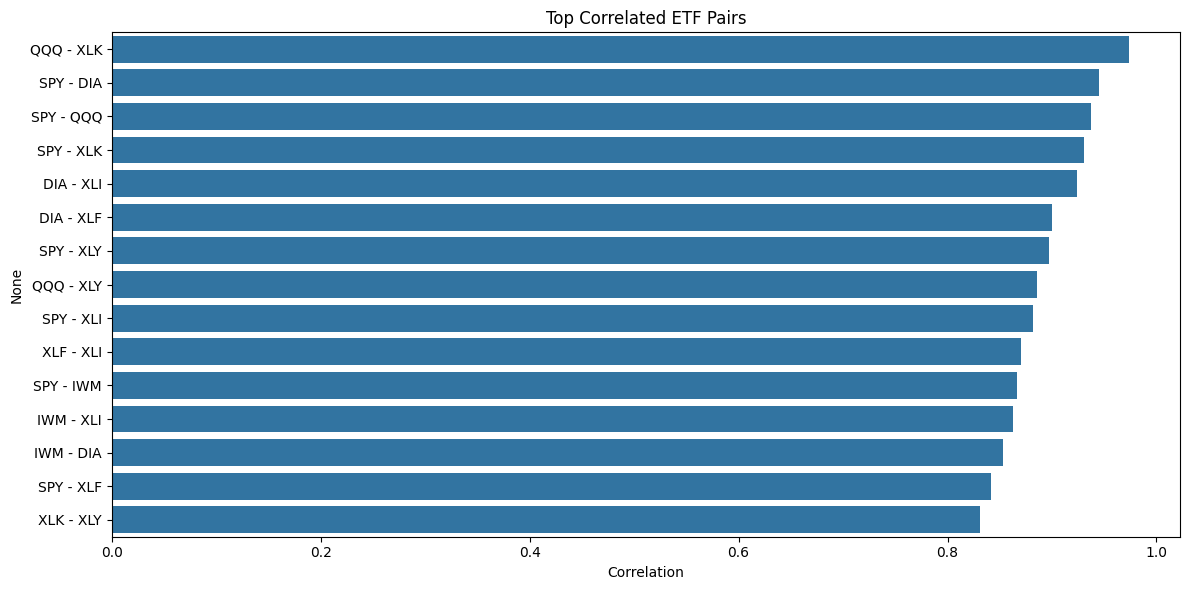

In [60]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_etf_pairs,
    x="Correlation",
    y=(
        top_etf_pairs["ETF_1"]
        + " - "
        + top_etf_pairs["ETF_2"]
    )
)

plt.title(
    "Top Correlated ETF Pairs"
)

plt.tight_layout()
plt.show()

## Interpretation of ETF Correlations

ETF correlations are generally expected to be high because ETFs represent diversified baskets of securities rather than individual companies.

Highly correlated ETF pairs often share:

- Similar market exposure
- Similar sector allocations
- Similar investment objectives

Examples include:

- SPY and DIA (broad US equity exposure)
- QQQ and XLK (technology-heavy exposure)
- XLF and KBE (financial sector exposure)

Unlike individual stocks, ETFs are less affected by company-specific events such as earnings surprises, management changes, or litigation.

As a result, ETF relationships are often more stable over time and may provide stronger candidates for long-term equilibrium analysis.

In [61]:
# ============================================================
# Average Correlation Comparison
# ============================================================

stock_corr_values = stock_corr.where(
    np.triu(
        np.ones(stock_corr.shape),
        k=1
    ).astype(bool)
).stack()

etf_corr_values = etf_corr.where(
    np.triu(
        np.ones(etf_corr.shape),
        k=1
    ).astype(bool)
).stack()

print(
    f"Average Stock Correlation: {stock_corr_values.mean():.3f}"
)

print(
    f"Average ETF Correlation: {etf_corr_values.mean():.3f}"
)

Average Stock Correlation: 0.366
Average ETF Correlation: 0.510


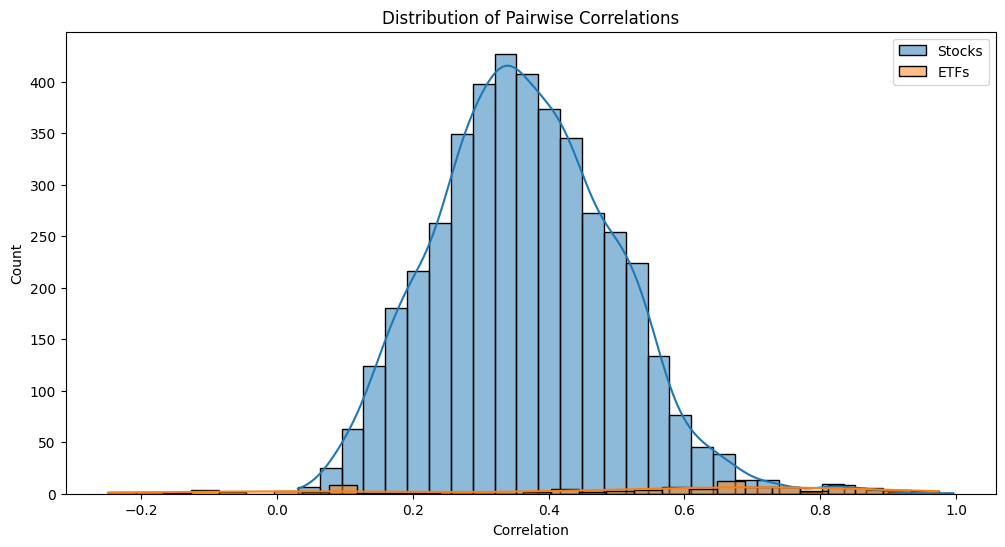

In [62]:
plt.figure(figsize=(12,6))

sns.histplot(
    stock_corr_values,
    bins=30,
    kde=True,
    label="Stocks"
)

sns.histplot(
    etf_corr_values,
    bins=30,
    kde=True,
    label="ETFs"
)

plt.legend()

plt.title(
    "Distribution of Pairwise Correlations"
)

plt.xlabel("Correlation")

plt.show()

In [63]:
stock_volatility = (
    stock_returns.std()
    * np.sqrt(252)
)

etf_volatility = (
    etf_returns.std()
    * np.sqrt(252)
)

comparison = pd.DataFrame({
    "Stocks":[stock_volatility.mean()],
    "ETFs":[etf_volatility.mean()]
})

comparison

,Stocks,ETFs
0,0.326743,0.212902


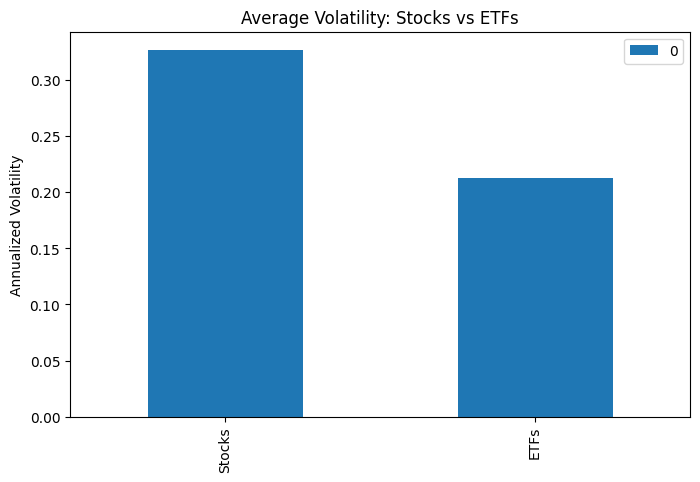

In [64]:
comparison.T.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel(
    "Annualized Volatility"
)

plt.title(
    "Average Volatility: Stocks vs ETFs"
)

plt.show()

## Stocks vs ETFs Comparison

The analysis reveals meaningful differences between individual stocks and ETFs.

### Correlation

ETFs generally exhibit higher average correlations because they represent diversified baskets of securities.

Individual stocks are influenced by:

- Earnings announcements
- Product launches
- Management decisions
- Company-specific events

which introduces additional noise into relationships.

### Volatility

Stocks typically exhibit higher volatility than ETFs because ETFs diversify away a portion of firm-specific risk.

### Implications for Cointegration

More stable relationships are generally preferred for pair trading and cointegration analysis.

Because ETFs are diversified portfolios, their correlations tend to be more persistent through time.

Individual stock relationships may offer larger opportunities but are also more vulnerable to structural breaks.

In [65]:
years = sorted(
    returns.index.year.unique()
)

years

[2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

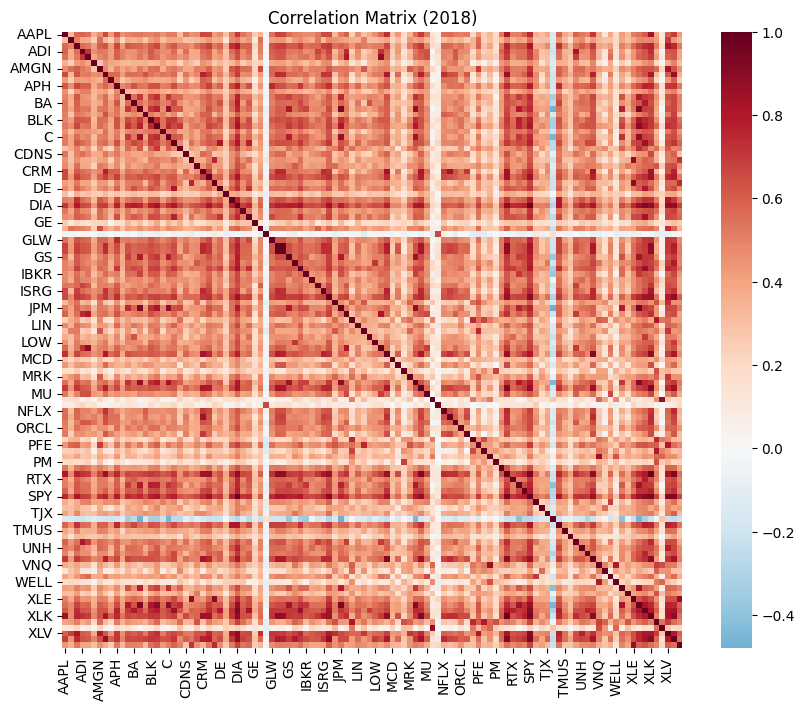

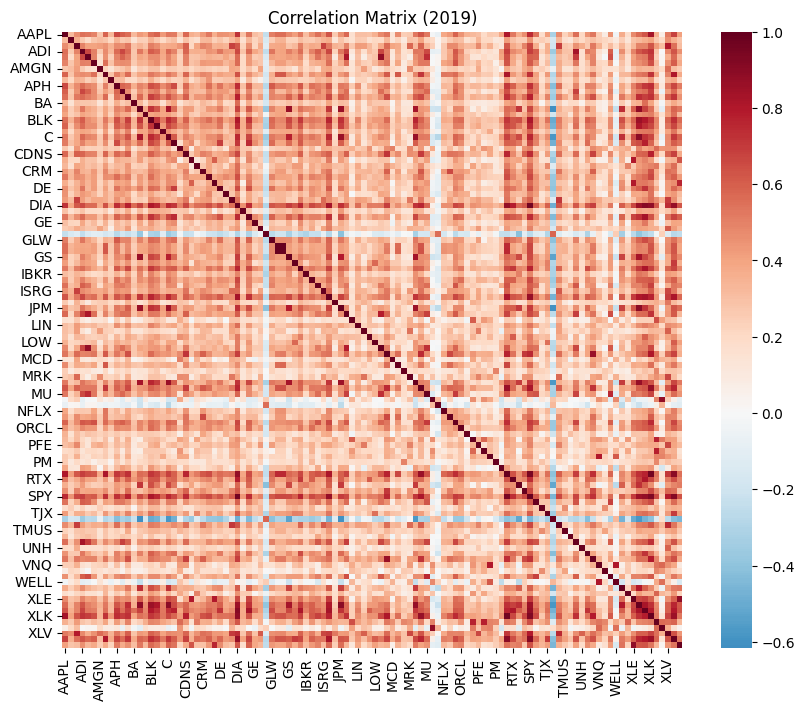

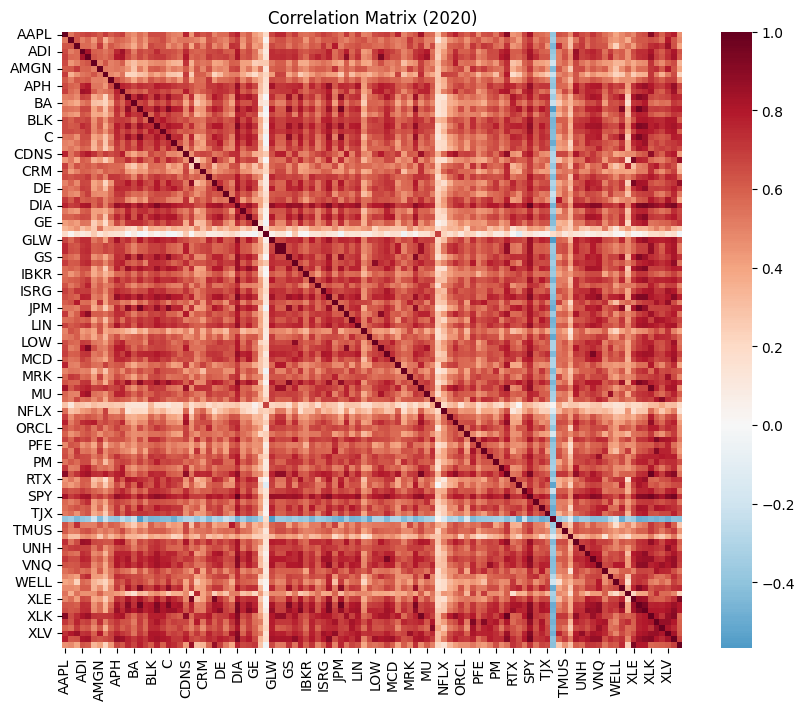

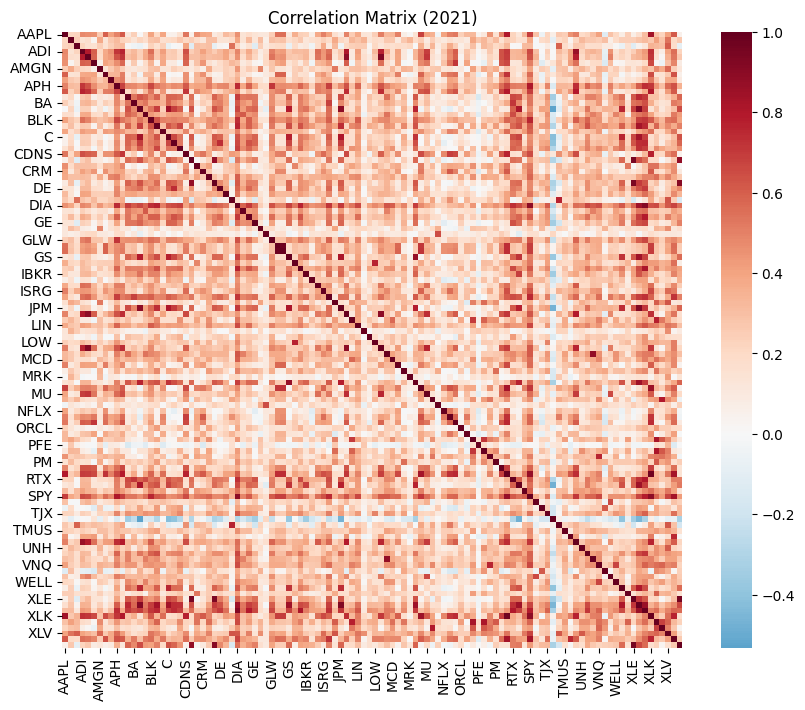

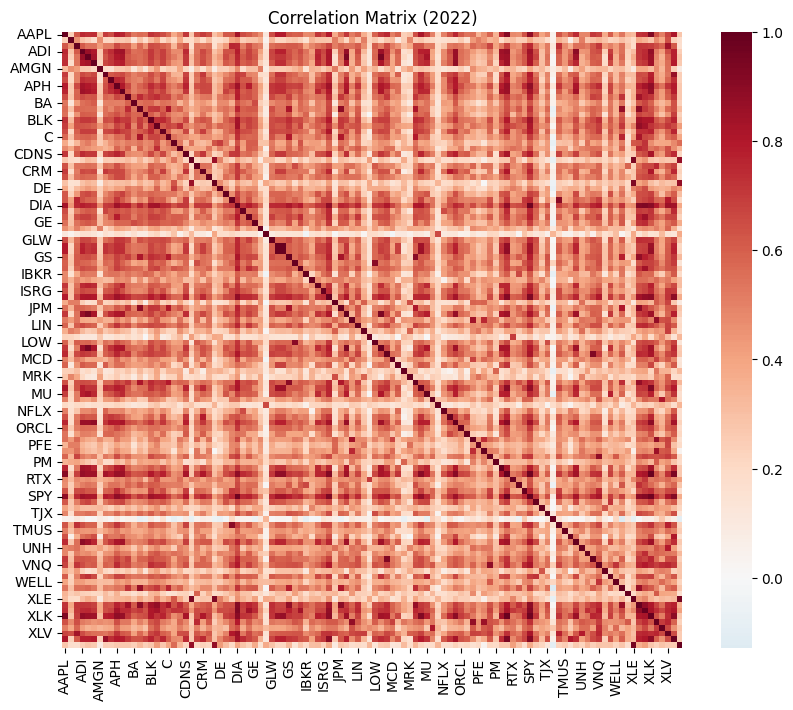

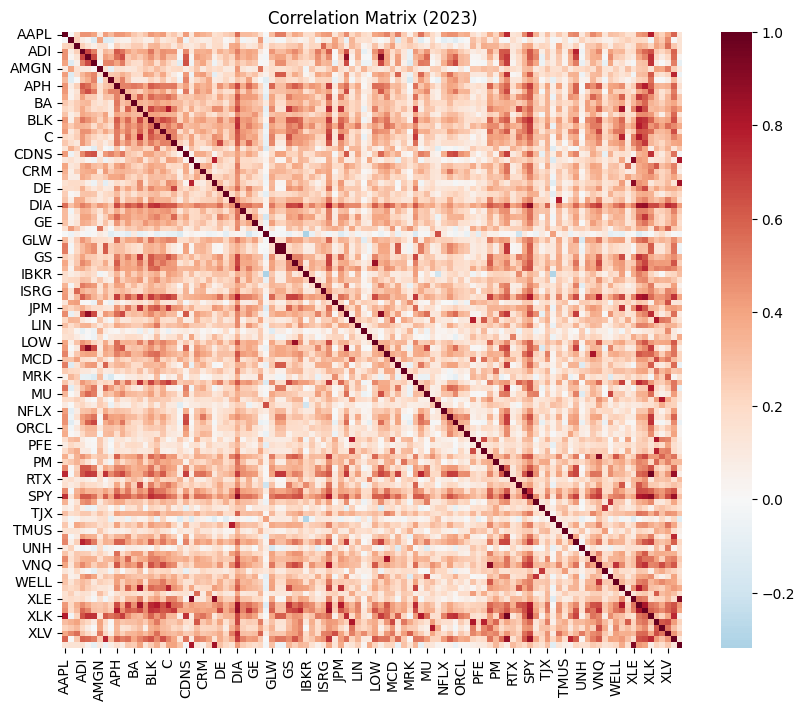

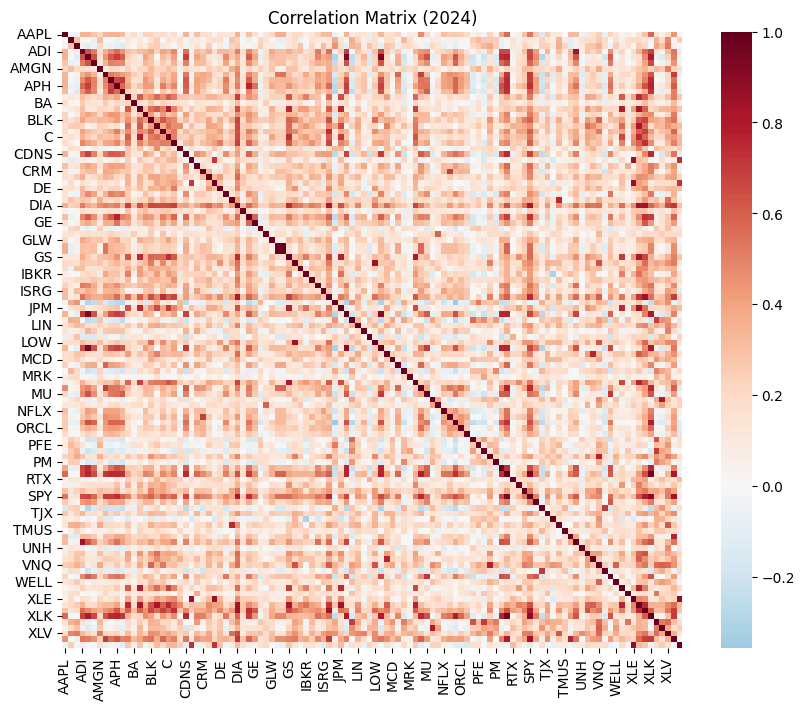

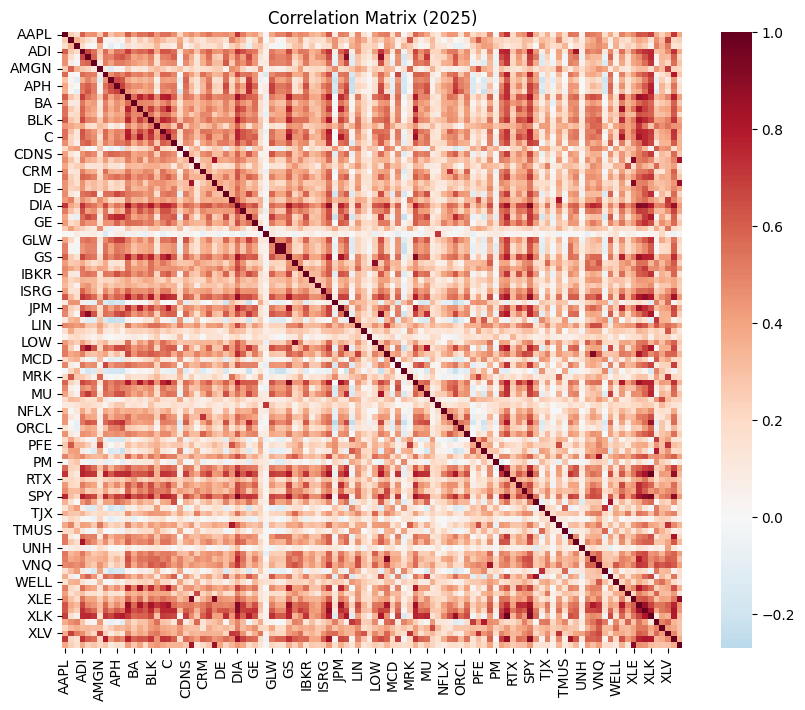

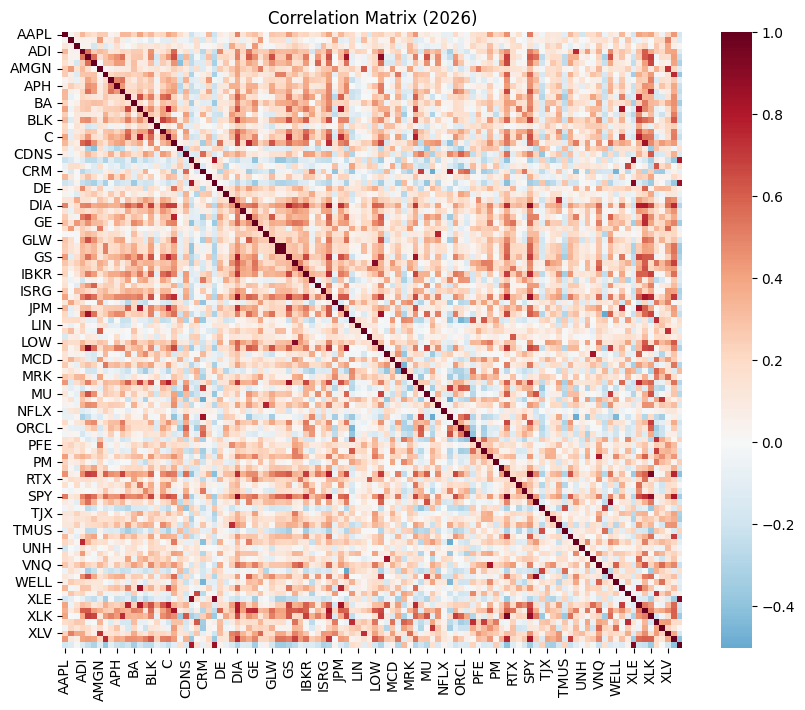

In [66]:
yearly_top_pairs = {}

for year in years:

    yearly_data = returns[
        returns.index.year == year
    ]

    corr_matrix = yearly_data.corr()

    plt.figure(figsize=(10,8))

    sns.heatmap(
        corr_matrix,
        cmap="RdBu_r",
        center=0
    )

    plt.title(
        f"Correlation Matrix ({year})"
    )

    plt.show()

    upper = corr_matrix.where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )

    pairs = (
        upper
        .stack()
        .sort_values(
            ascending=False
        )
        .head(5)
    )

    yearly_top_pairs[year] = pairs

In [67]:
for year, pairs in yearly_top_pairs.items():

    print("\n")
    print("="*50)

    print(
        f"Top Correlated Pairs - {year}"
    )

    print("="*50)

    print(pairs)



Top Correlated Pairs - 2018
GOOG  GOOGL    0.993665
QQQ   XLK      0.984705
DIA   SPY      0.973332
JPM   XLF      0.947300
QQQ   SPY      0.945788
dtype: float64


Top Correlated Pairs - 2019
GOOG  GOOGL    0.997358
QQQ   XLK      0.962146
DIA   SPY      0.957569
QQQ   SPY      0.946570
SPY   XLK      0.929530
dtype: float64


Top Correlated Pairs - 2020
GOOG  GOOGL    0.997560
QQQ   XLK      0.984404
DIA   SPY      0.982438
JPM   XLF      0.963511
BAC   XLF      0.958425
dtype: float64


Top Correlated Pairs - 2021
GOOG  GOOGL    0.977775
QQQ   XLK      0.966486
XLE   XOM      0.952769
COP   XLE      0.941012
CVX   XLE      0.934230
dtype: float64


Top Correlated Pairs - 2022
GOOG  GOOGL    0.997795
QQQ   XLK      0.983196
      SPY      0.967015
DIA   SPY      0.965913
SPY   XLK      0.965012
dtype: float64


Top Correlated Pairs - 2023
GOOG  GOOGL    0.997488
QQQ   XLK      0.958991
XLE   XOM      0.918845
QQQ   SPY      0.916760
AMAT  LRCX     0.904733
dtype: float64


Top Corr

In [103]:
from collections import Counter

pair_counter = Counter()

for year, pairs in yearly_top_pairs.items():

    for pair in pairs.index:

        pair_name = f"{pair[0]} - {pair[1]}"

        pair_counter[pair_name] += 1

pair_frequency = (
    pd.DataFrame(
        pair_counter.items(),
        columns=[
            "Pair",
            "Years Appeared in Top 5"
        ]
    )
    .sort_values(
        "Years Appeared in Top 5",
        ascending=False
    )
)

pair_frequency

,Pair,Years Appeared in Top 5
0,GOOG - GOOGL,9
1,QQQ - XLK,9
4,QQQ - SPY,7
2,DIA - SPY,5
5,SPY - XLK,3
7,XLE - XOM,3
3,JPM - XLF,2
9,CVX - XLE,2
10,AMAT - LRCX,2
6,BAC - XLF,1


Year-wise Observations
GOOG-GOOGL remained the strongest correlation throughout the sample period due to representing different share classes of the same company.
QQQ-XLK consistently appeared among the top correlated pairs, reflecting the heavy technology exposure of both ETFs.
DIA-SPY showed persistent correlation as both track broad U.S. equity markets.
XLE-XOM emerged prominently during the energy sector rally of 2021–2023.
AMAT-LRCX became one of the strongest stock-stock relationships during the semiconductor expansion of 2023–2024.

In [71]:
etfs = [
    'SPY', 'QQQ', 'DIA',
    'XLK', 'XLF', 'XLE',
    'XLI', 'XLY'
]

stock_cols = [col for col in returns.columns if col not in etfs]

stock_returns = returns[stock_cols]


In [72]:
stock_corr = stock_returns.corr()

upper = stock_corr.where(
    np.triu(np.ones(stock_corr.shape), k=1).astype(bool)
)

stock_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={
             'level_0': 'Stock1',
             'level_1': 'Stock2',
             0: 'Correlation'
         })
         .sort_values('Correlation', ascending=False)
)

stock_pairs.head(20)

,Stock1,Stock2,Correlation
3637,GOOG,GOOGL,0.995733
454,AMAT,LRCX,0.910904
5589,MA,V,0.902686
4854,KLAC,LRCX,0.886498
448,AMAT,KLAC,0.883814
1347,BAC,JPM,0.881546
3860,GS,MS,0.867667
1318,BAC,C,0.862913
1394,BAC,WFC,0.845897
2699,CVX,XOM,0.843423


In [79]:

company_info = {}

for ticker in stock_cols:
    try:
        company_info[ticker] = yf.Ticker(ticker).info.get("longName")
    except:
        company_info[ticker] = None


def clean_company_name(name):

    if pd.isna(name) or name is None:
        return None

    remove_words = [
        "Class A",
        "Class B",
        "Class C",
        "Common Stock"
    ]

    for word in remove_words:
        name = name.replace(word, "")

    return name.strip()


stock_pairs["Company1"] = stock_pairs["Stock1"].map(
    lambda x: clean_company_name(company_info.get(x))
)

stock_pairs["Company2"] = stock_pairs["Stock2"].map(
    lambda x: clean_company_name(company_info.get(x))
)

stock_pairs = stock_pairs[
    stock_pairs["Company1"] != stock_pairs["Company2"]
]

In [80]:
top_stock_pairs = stock_pairs.head(5)

top_stock_pairs

,Stock1,Stock2,Correlation,Company1,Company2
454,AMAT,LRCX,0.910904,"Applied Materials, Inc.",Lam Research Corporation
5589,MA,V,0.902686,Mastercard Incorporated,Visa Inc.
4854,KLAC,LRCX,0.886498,KLA Corporation,Lam Research Corporation
448,AMAT,KLAC,0.883814,"Applied Materials, Inc.",KLA Corporation
1347,BAC,JPM,0.881546,Bank of America Corporation,JPMorgan Chase & Co.


In [91]:
stock_pairs_to_plot = list(
    zip(
        top_stock_pairs["Stock1"],
        top_stock_pairs["Stock2"]
    )
)

print(stock_pairs_to_plot)

[('AMAT', 'LRCX'), ('MA', 'V'), ('KLAC', 'LRCX'), ('AMAT', 'KLAC'), ('BAC', 'JPM')]


In [84]:
etf_corr = etf_returns.corr()

upper_etf = etf_corr.where(
    np.triu(
        np.ones(etf_corr.shape),
        k=1
    ).astype(bool)
)

etf_pairs = (
    upper_etf.stack()
    .reset_index()
    .rename(columns={
        "level_0":"ETF1",
        "level_1":"ETF2",
        0:"Correlation"
    })
    .sort_values(
        "Correlation",
        ascending=False
    )
)

etf_pairs

,ETF1,ETF2,Correlation
19,QQQ,XLK,0.973835
3,SPY,DIA,0.945355
1,SPY,QQQ,0.937773
4,SPY,XLK,0.930450
55,DIA,XLI,0.923974
...,...,...,...
220,TLT,XLI,NaN
221,TLT,XLU,NaN
222,TLT,VNQ,NaN
223,TLT,GLD,NaN


In [88]:
top_etf_pairs = etf_pairs.head(5)

etf_pairs_to_plot = list(
    zip(
        top_etf_pairs["ETF1"],
        top_etf_pairs["ETF2"]
    )
)
top_etf_pairs

,ETF1,ETF2,Correlation
19,QQQ,XLK,0.973835
3,SPY,DIA,0.945355
1,SPY,QQQ,0.937773
4,SPY,XLK,0.930450
55,DIA,XLI,0.923974


In [95]:
def compute_rolling_corr(
    data,
    asset1,
    asset2,
    window=252
):
    return (
        data[asset1]
        .rolling(window)
        .corr(data[asset2])
    )

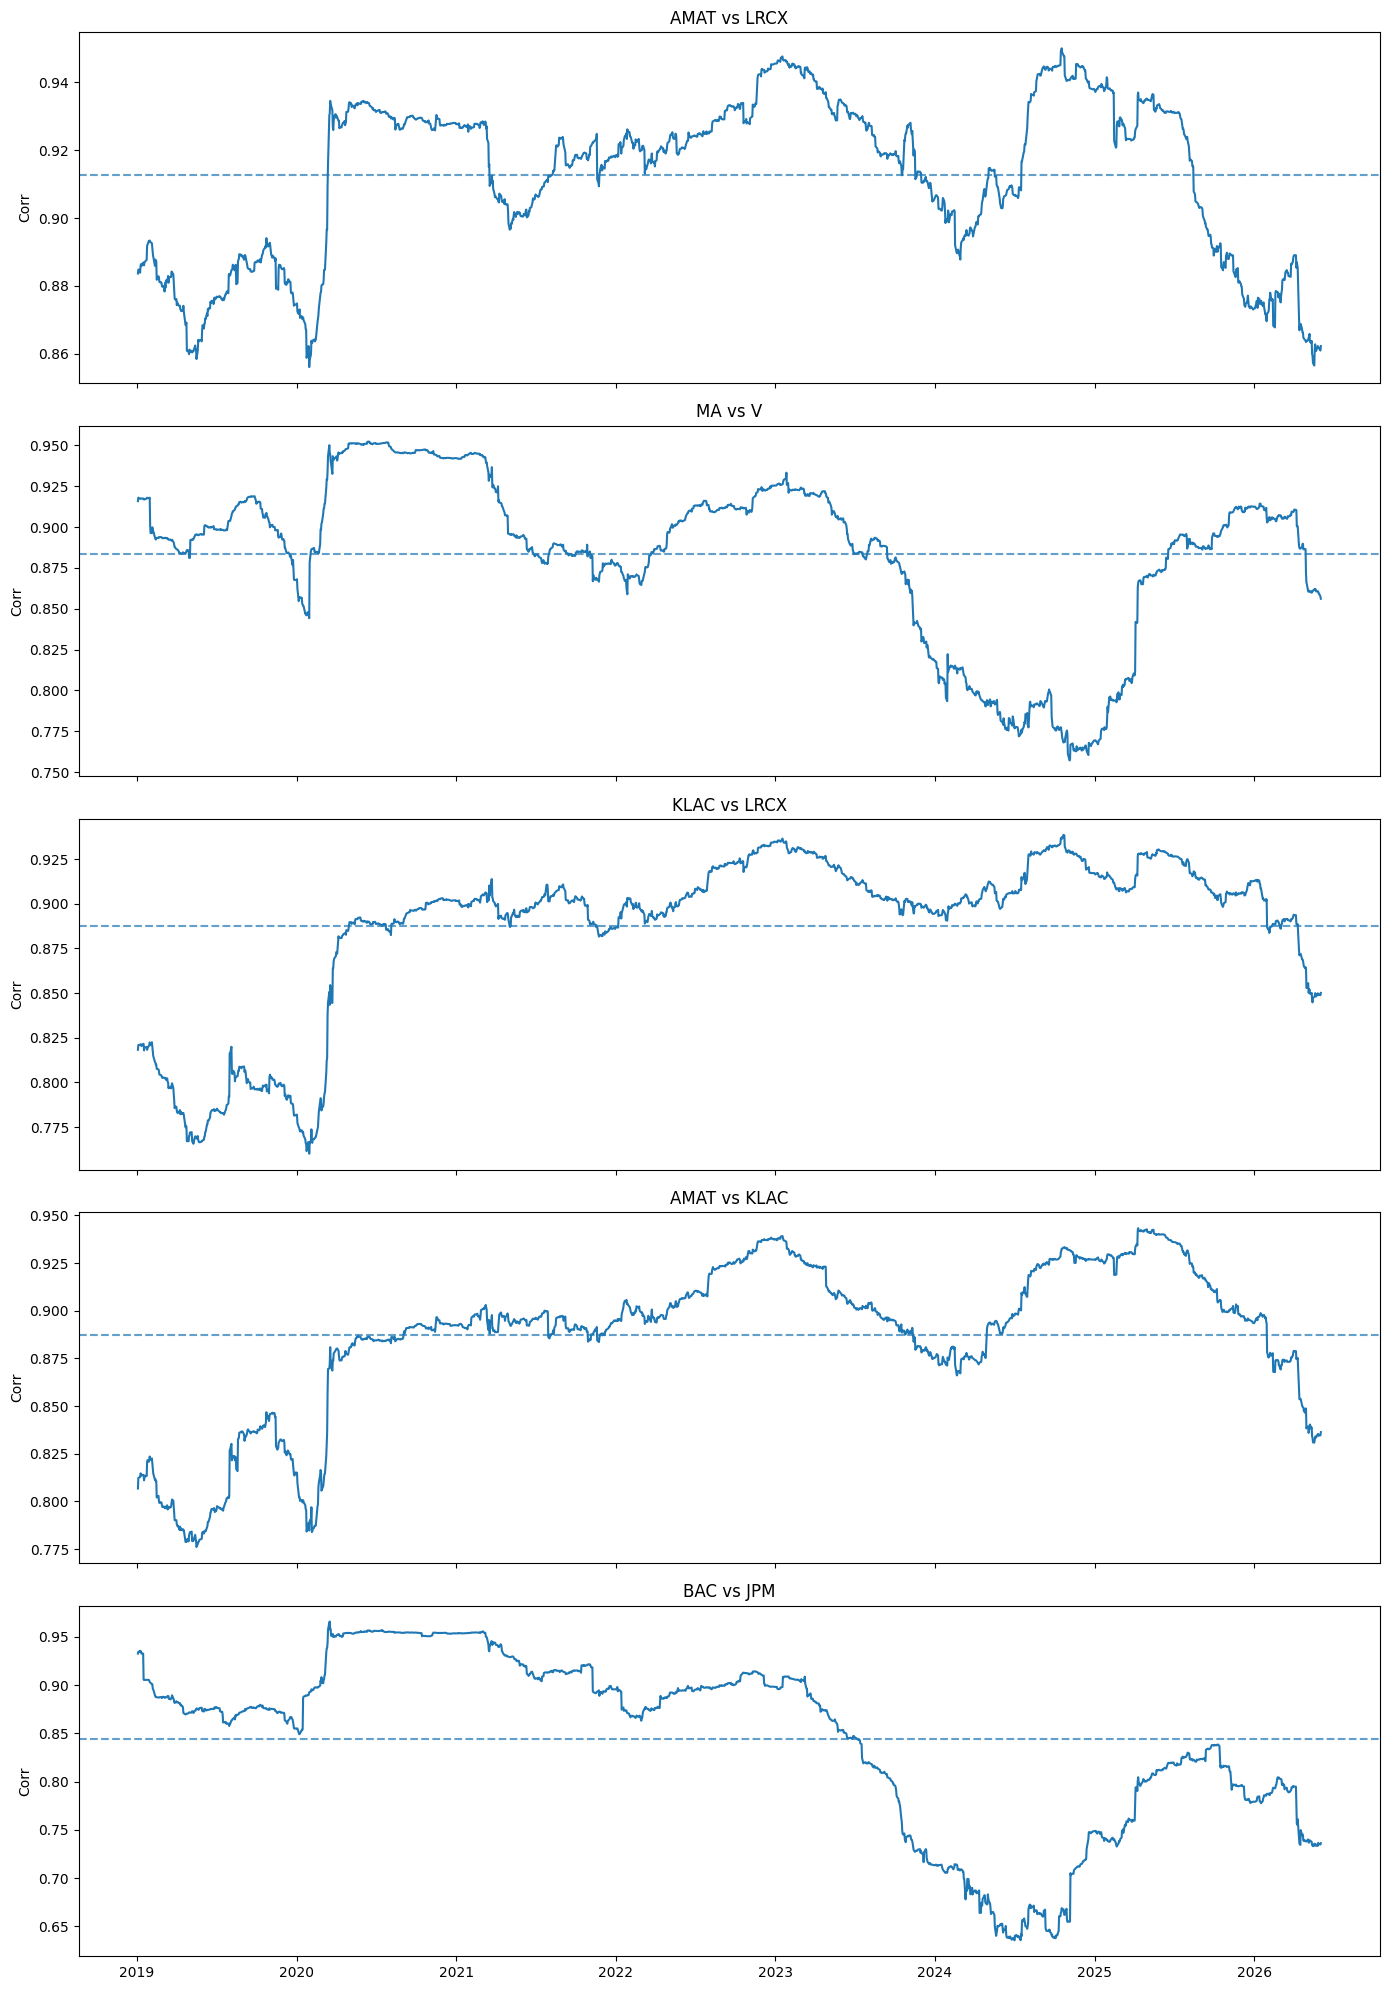

In [96]:
fig, axes = plt.subplots(
    len(stock_pairs_to_plot),
    1,
    figsize=(14, 4 * len(stock_pairs_to_plot)),
    sharex=True
)

for ax, (s1, s2) in zip(axes, stock_pairs_to_plot):

    rolling_corr = compute_rolling_corr(
        stock_returns,
        s1,
        s2,
        252
    )

    ax.plot(
        rolling_corr.index,
        rolling_corr
    )

    ax.axhline(
        rolling_corr.mean(),
        linestyle="--",
        alpha=0.7
    )

    ax.set_title(
        f"{s1} vs {s2}"
    )

    ax.set_ylabel("Corr")

plt.tight_layout()
plt.show()

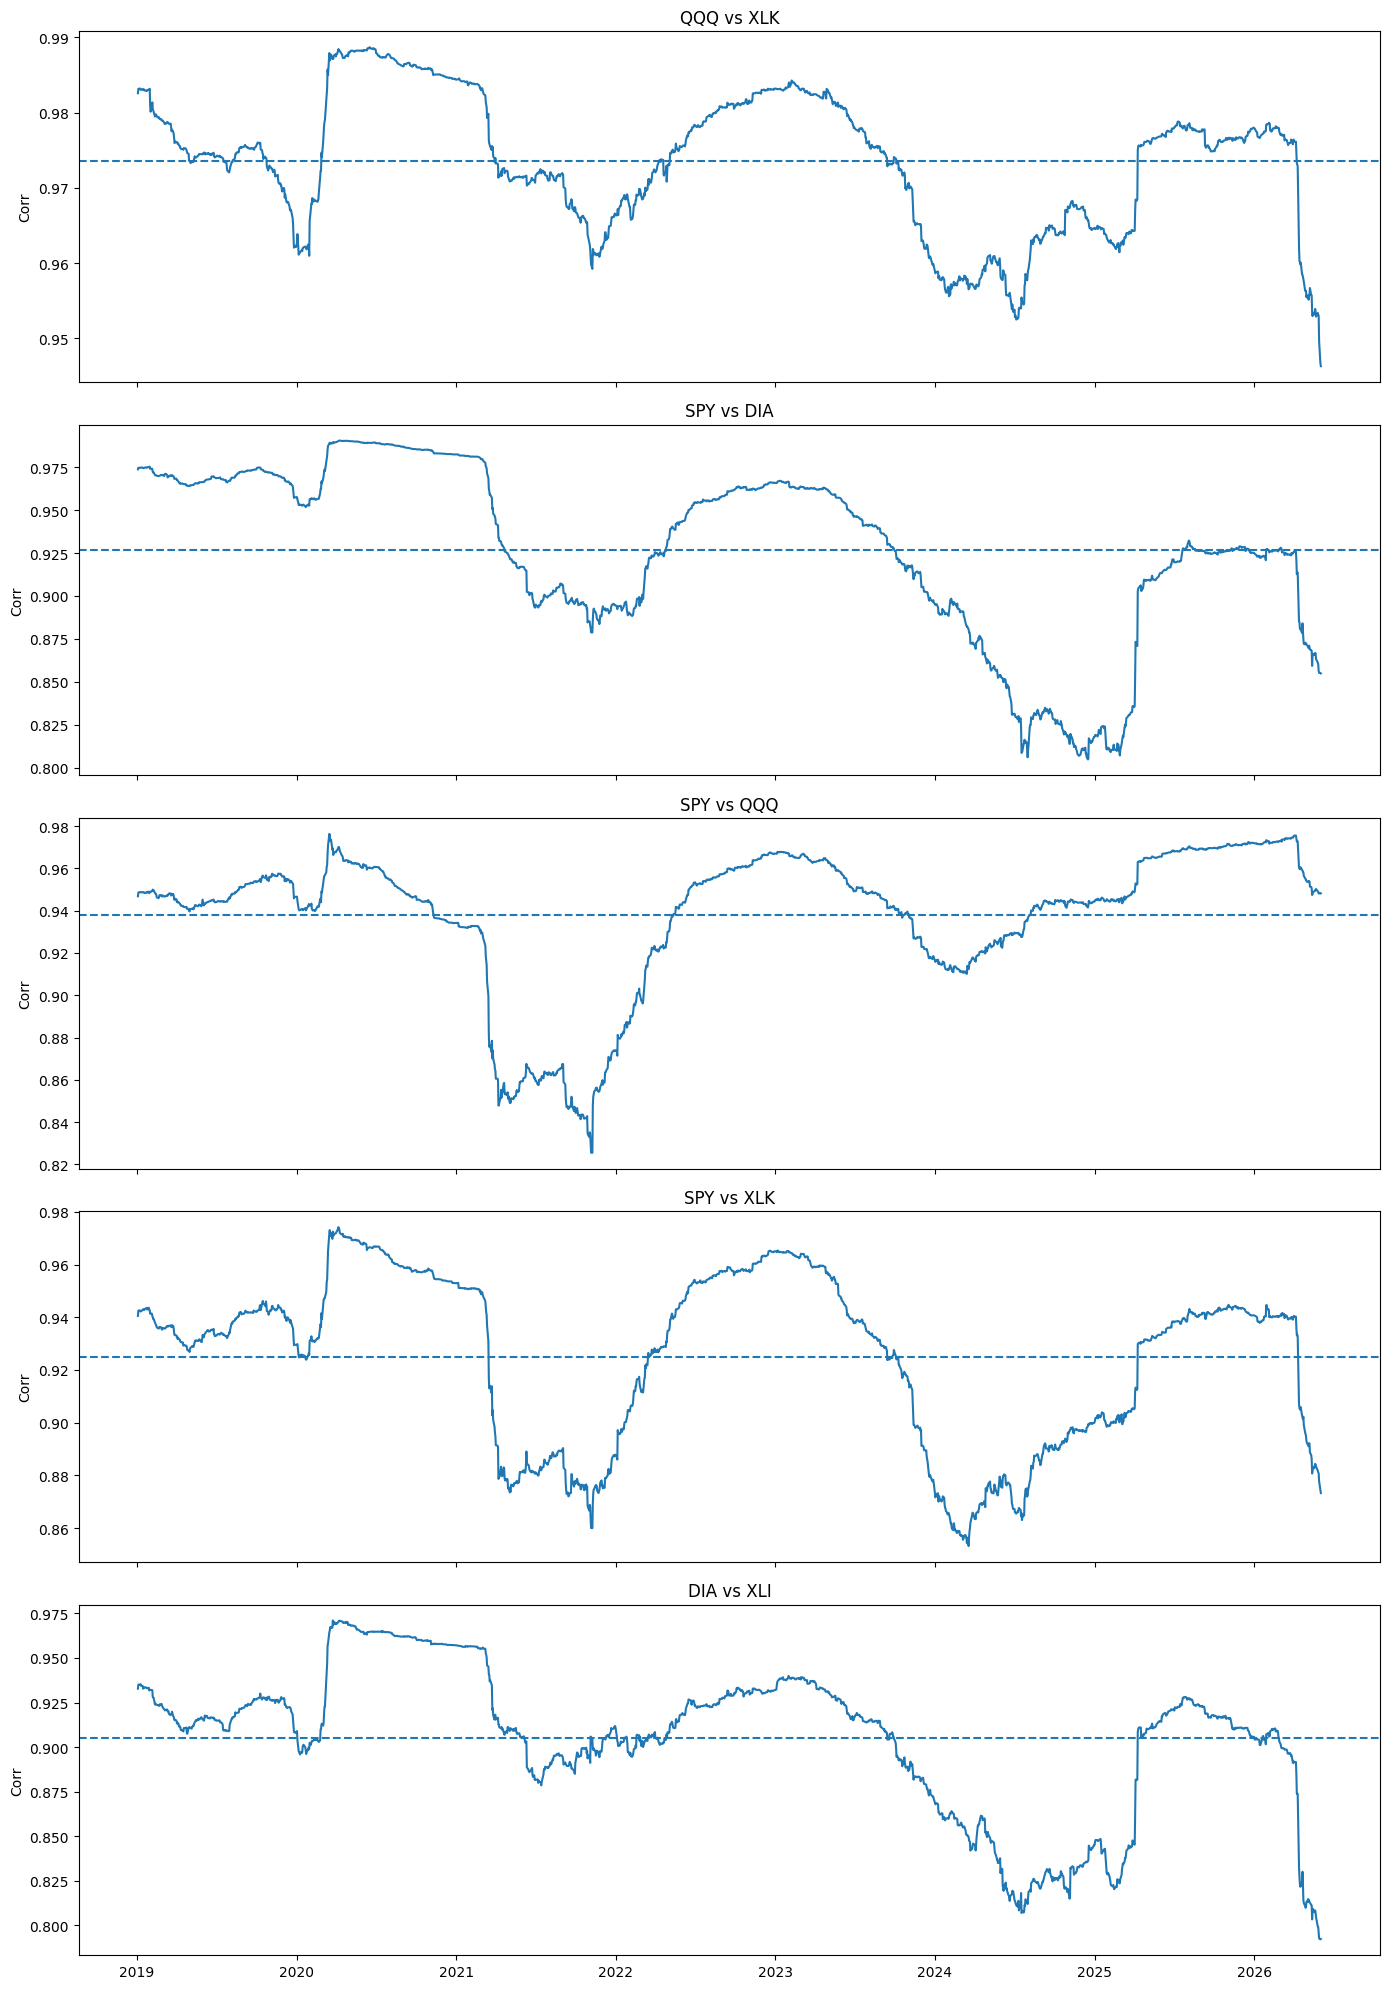

In [99]:
fig, axes = plt.subplots(
    len(etf_pairs_to_plot),
    1,
    figsize=(14, 4 * len(etf_pairs_to_plot)),
    sharex=True
)

for ax, (e1, e2) in zip(
    axes,
    etf_pairs_to_plot
):

    rcorr = compute_rolling_corr(
        etf_returns,
        e1,
        e2,
        252
    )

    ax.plot(
        rcorr.index,
        rcorr
    )

    ax.axhline(
        rcorr.mean(),
        linestyle="--"
    )

    ax.set_title(
        f"{e1} vs {e2}"
    )

    ax.set_ylabel("Corr")

plt.tight_layout()
plt.show()

In [100]:
summary = []

for s1, s2 in stock_pairs_to_plot:

    rcorr = compute_rolling_corr(
        stock_returns,
        s1,
        s2
    ).dropna()

    summary.append({
        "Pair": f"{s1}-{s2}",
        "Static Corr": stock_corr.loc[s1, s2],
        "Mean Rolling Corr": rcorr.mean(),
        "Min Rolling Corr": rcorr.min(),
        "Max Rolling Corr": rcorr.max()
    })

rolling_summary = pd.DataFrame(summary)

rolling_summary.sort_values(
    "Mean Rolling Corr",
    ascending=False
)

,Pair,Static Corr,Mean Rolling Corr,Min Rolling Corr,Max Rolling Corr
0,AMAT-LRCX,0.910904,0.912643,0.856078,0.950019
2,KLAC-LRCX,0.886498,0.887361,0.760138,0.938575
3,AMAT-KLAC,0.883814,0.887172,0.776085,0.943273
1,MA-V,0.902686,0.883356,0.757130,0.952315
4,BAC-JPM,0.881546,0.844399,0.635664,0.966007


In [101]:
etf_summary = []

for e1, e2 in etf_pairs_to_plot:

    rcorr = compute_rolling_corr(
        etf_returns,
        e1,
        e2
    ).dropna()

    etf_summary.append({
        "Pair": f"{e1}-{e2}",
        "Static Corr": etf_corr.loc[e1, e2],
        "Mean Rolling Corr": rcorr.mean(),
        "Min Rolling Corr": rcorr.min(),
        "Max Rolling Corr": rcorr.max()
    })

etf_summary = pd.DataFrame(etf_summary)

etf_summary

,Pair,Static Corr,Mean Rolling Corr,Min Rolling Corr,Max Rolling Corr
0,QQQ-XLK,0.973835,0.973617,0.946303,0.988671
1,SPY-DIA,0.945355,0.926888,0.804716,0.990506
2,SPY-QQQ,0.937773,0.937759,0.825476,0.976342
3,SPY-XLK,0.930450,0.924974,0.853178,0.974170
4,DIA-XLI,0.923974,0.905100,0.792215,0.971049


Key Findings
-The strongest stock-stock correlations were observed among firms operating within the same industries.
-Semiconductor and financial sector stocks displayed particularly strong relationships.
-ETF correlations were generally more stable than stock correlations due to diversification.
-Year-wise analysis showed that the strongest relationships changed across market regimes.
-Rolling correlation analysis revealed that some relationships remained persistent while others weakened during periods of market stress.
-The identified highly correlated pairs will be examined further using cointegration techniques in the next notebook.